In [3]:
library(repr)
library(tidyverse)
library(gtsummary)
library(broom)
library(broom.mixed)
library(gt)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
options(bitmapType = 'cairo')
library(showtext)
font_add_google("Lato", "lato")
font_add_google(name = "Roboto", family = "roboto")
showtext_opts(dpi = 300)
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [5]:
df <- read_csv("median_io_group_gaze.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# df |> ggplot(aes(x = group, y = median_clusterDuration, color = building_location)) +
#  geom_point(position = position_dodge(0.4)) +
#  theme_minimal()
df |> head()

PID,hitObjectColliderName,group,building_location,GroupCount,median_clusterDuration
<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>
4003,Building_100,peripheral,outside,10,0.4109216
4003,Building_101,peripheral,outside,8,0.4438699
4003,Building_102,peripheral,outside,15,0.3658845
4003,Building_131,peripheral,outside,2,0.5775331
4003,Building_132,peripheral,outside,3,0.3659341
4003,Building_139,peripheral,outside,7,0.3102803


Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_density()`).”


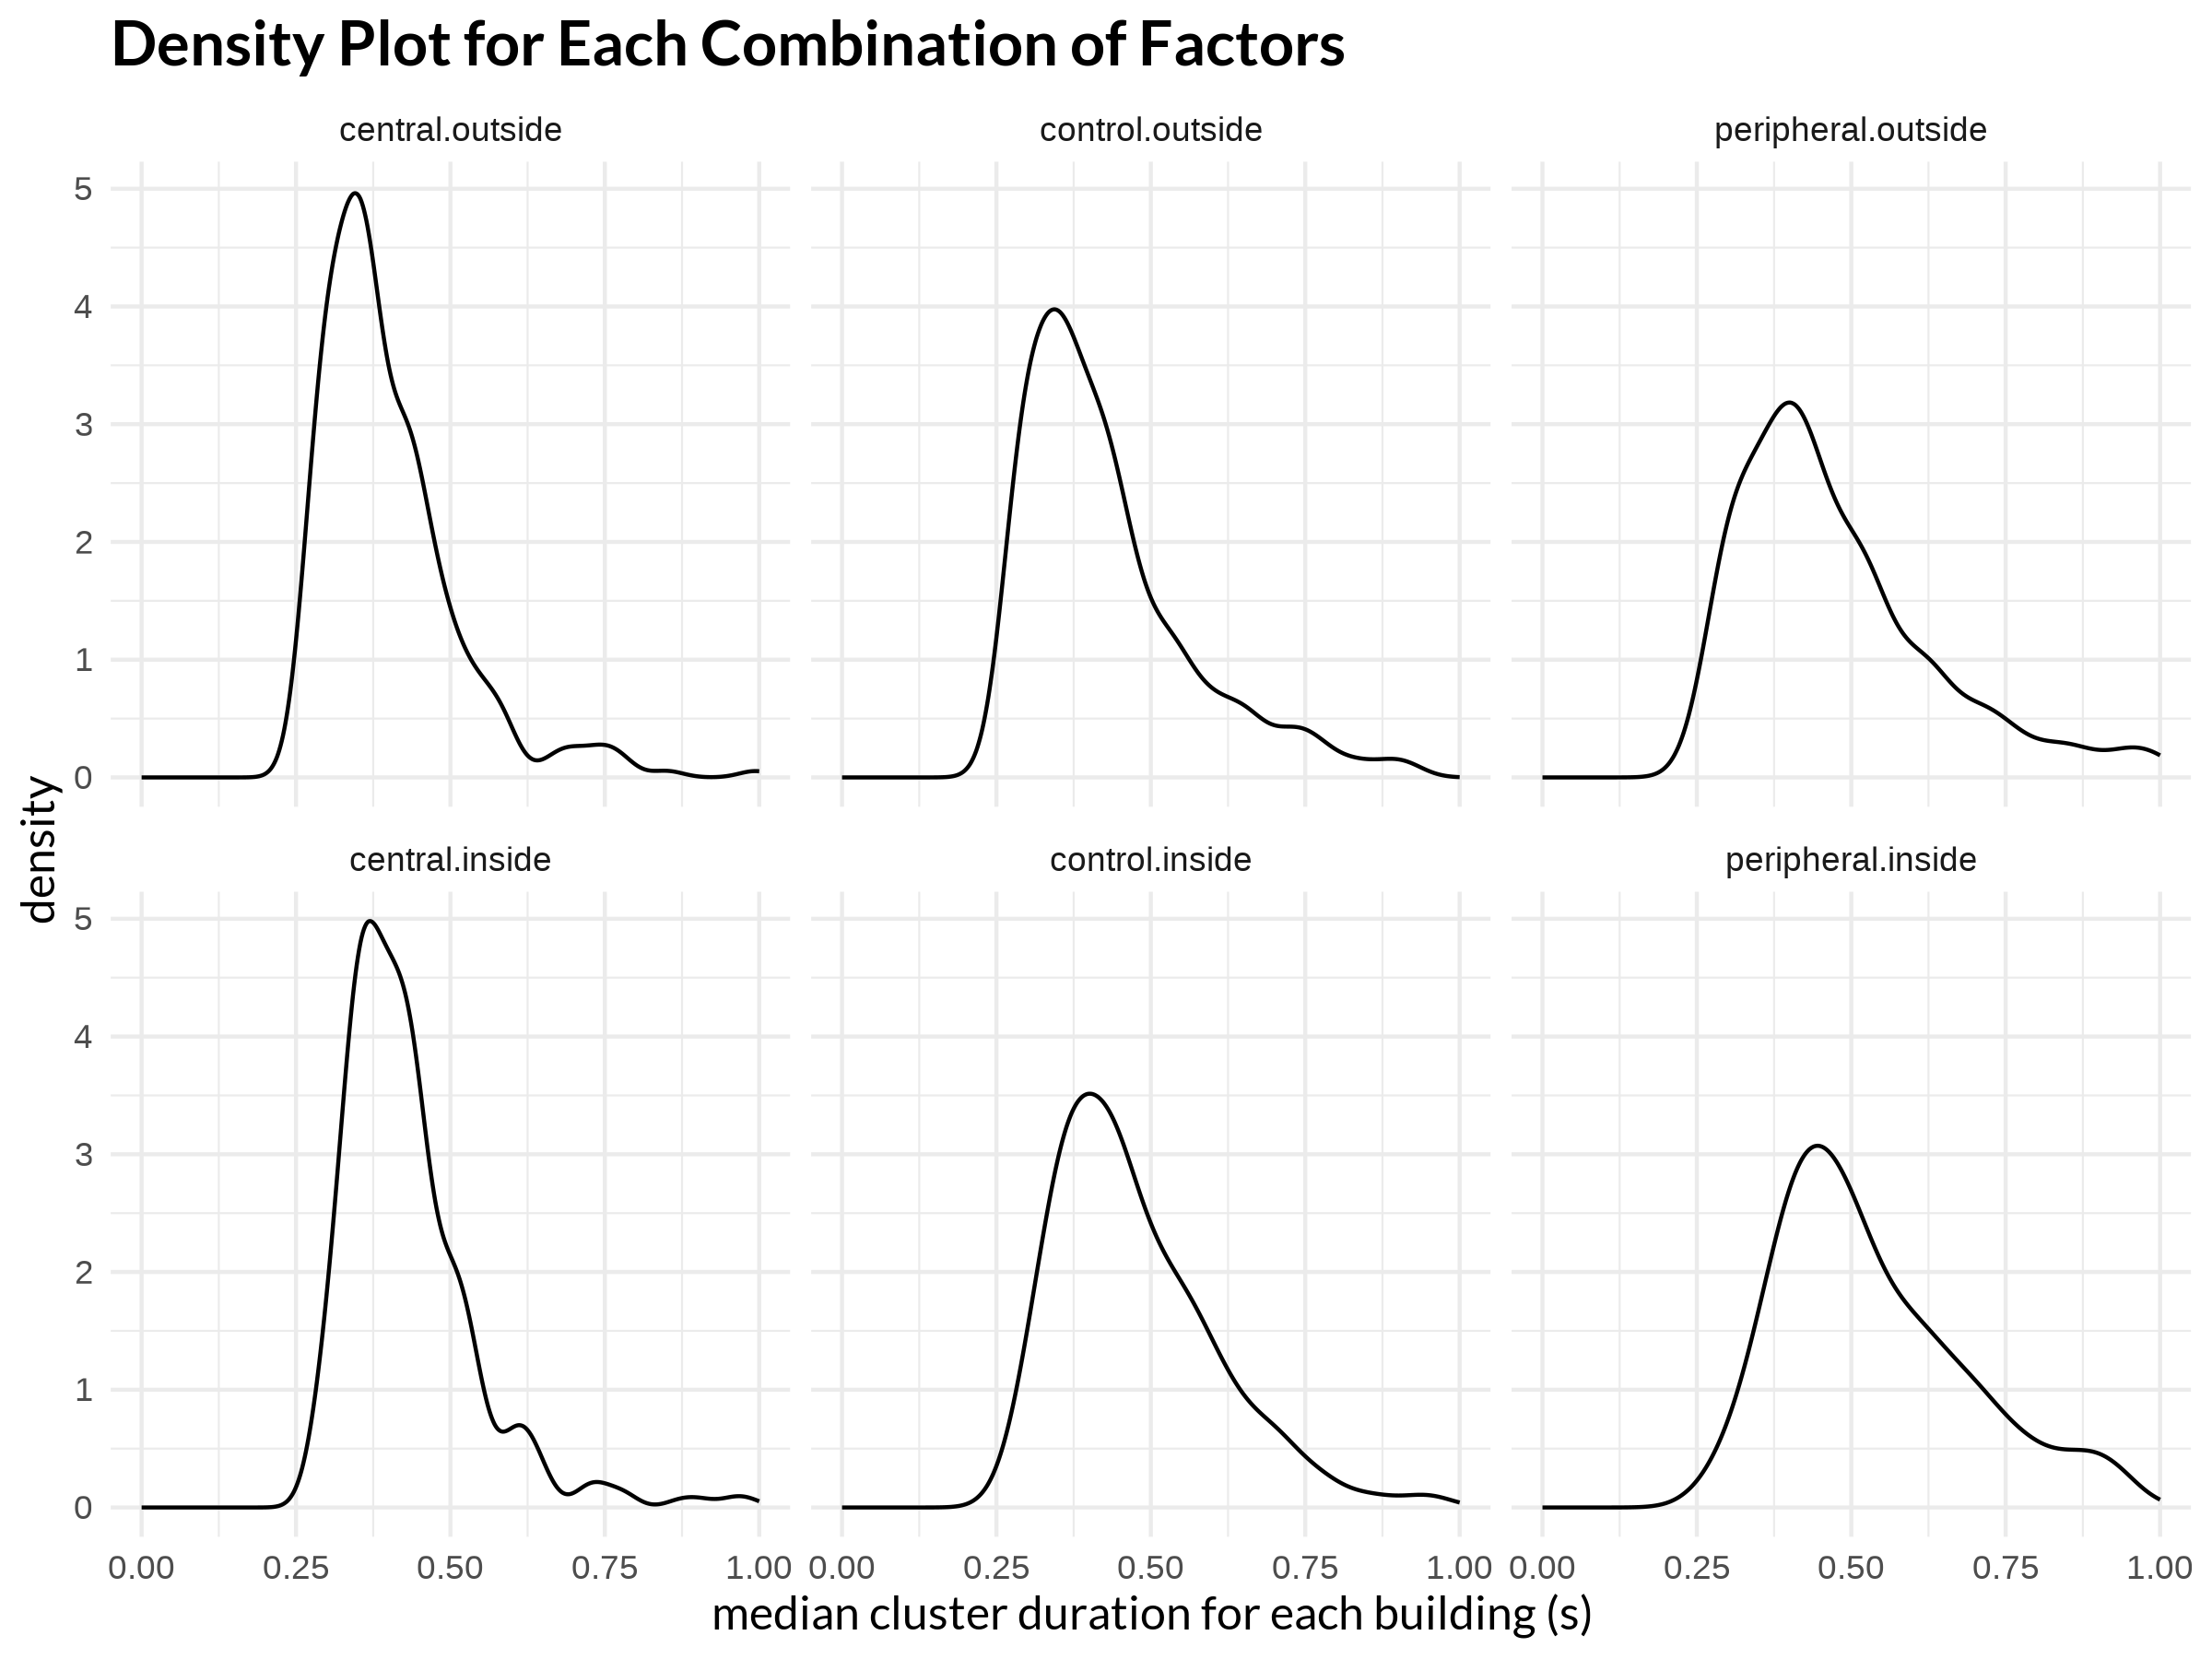

In [7]:
fig <- df |>
  ggplot(aes(x = median_clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0, 1) +
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density") +
  theme(
    plot.title = element_text(family = "lato", size = 16, face = "bold"),
    axis.title.x = element_text(family = "lato", size = 12),
    axis.title.y = element_text(family = "lato", size = 12)
   )
fig
#ggsave("naisu_only_location.svg", fig)

In [8]:
library(lme4)
library(emmeans)
library(performance)
library(MASS)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: ‘MASS’


The following object is masked from ‘package:gtsummary’:

    select


The following object is masked from ‘package:dplyr’:

    select




In [28]:
# Fit a generalized linear mixed model (GLMM) using glmer
model_0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
model_inter <- glmer(median_clusterDuration ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
df <- df %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )
model_full <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
# model0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))


In [ ]:
# model_0 %>%
#     tidy()
# model_0 %>% 
#     tbl_regression(exponentiate = FALSE)

model_0 %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
model_inter %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
model_full %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.4182184,0.09004833,26.85467,7.438765e-159
ran_pars,hitObjectColliderName,sd__(Intercept),0.3045742,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1770540,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3722071,NA,NA,NA


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.5112568,0.09244778,27.164056,1.727658e-162
fixed,NA,building_locationinside,-0.3550313,0.09617319,-3.691583,2.228623e-04
ran_pars,hitObjectColliderName,sd__(Intercept),0.2857366,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1784392,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3698834,NA,NA,NA


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.4993140,0.09236443,27.059270,2.971212e-161
fixed,NA,building_locationinside,-0.3544623,0.09636720,-3.678246,2.348430e-04
fixed,NA,groupperipheral,-0.2996690,0.09521554,-3.147270,1.648025e-03
fixed,NA,groupcentral,0.1873750,0.09363147,2.001197,4.537122e-02
ran_pars,hitObjectColliderName,sd__(Intercept),0.2845363,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1202008,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3687638,NA,NA,NA


In [10]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        duration = clusterDuration
    ) |>
    group_by(PID, group, hitObjectColliderName, building_location) |>
    summarize(
        mean_connections = mean(connections)
    ) |>
    ungroup() |>
    filter(mean_connections > 0)

Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'PID', 'group', 'hitObjectColliderName'.
You can override using the `.groups` argument.


In [189]:
overdisp_fun <- function(model) {
    rdf <- df.residual(model)
    rp <- residuals(model,type="pearson")
    Pearson.chisq <- sum(rp^2)
    prat <- Pearson.chisq/rdf
    pval <- pchisq(Pearson.chisq, df=rdf, lower.tail=FALSE)
    c(chisq=Pearson.chisq,ratio=prat,rdf=rdf,p=pval)
}

tidy_quasi <- function(model, phi=overdisp_fun(model)["ratio"],
                       conf.level=0.95) {
    tt <- (tidy(model, effects="fixed")
       %>% mutate(std.error=std.error*sqrt(phi),
                   statistic=estimate/std.error,
                   p.value=2*pnorm(abs(statistic), lower.tail=FALSE))
    )
    return(tt)
}

In [186]:
node_model_0 <- glmer(mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_inter <- glmer(mean_connections ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
df_node <- df_node %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )
node_model_full <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())

In [194]:
node_model_0 %>% summary()

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName)
   Data: df_node

      AIC       BIC    logLik -2*log(L)  df.resid 
   8263.3    8279.9   -4128.7    8257.3      1823 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7781 -0.6208 -0.1087  0.5087  3.8685 

Random effects:
 Groups                Name        Variance Std.Dev.
 hitObjectColliderName (Intercept) 0.39295  0.6269  
 PID                   (Intercept) 0.07708  0.2776  
Number of obs: 1826, groups:  hitObjectColliderName, 127; PID, 24

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.31513    0.08378    15.7   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [191]:
node_model_0 %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
node_model_0 %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
node_model_inter %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
node_model_full %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()

effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.315133,0.07218527,18.21886,3.65693e-74


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),1.3151333,0.08377707,15.69801,1.560627e-55
ran_pars,hitObjectColliderName,sd__(Intercept),0.6268563,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.2776285,NA,NA,NA


effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.0369189,0.07236746,14.32852,1.451743e-46
fixed,building_locationinside,0.8681066,0.08399543,10.33516,4.885750e-25


effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.1714972,0.09603270,12.198941,3.148944e-34
fixed,building_locationinside,0.8682046,0.08404268,10.330521,5.128131e-25
fixed,groupperipheral,-0.2108949,0.11392431,-1.851184,6.414305e-02
fixed,groupcentral,-0.1931710,0.11382446,-1.697096,8.967848e-02


In [180]:
 node_model_0 %>% summary()

Linear mixed-effects model fit by maximum likelihood
  Data: df_node 
  AIC BIC logLik
   NA  NA     NA

Random effects:
 Formula: ~1 | PID
        (Intercept)
StdDev:   0.2348749

 Formula: ~1 | hitObjectColliderName %in% PID
         (Intercept) Residual
StdDev: 1.895109e-06 1.466472

Variance function:
 Structure: fixed weights
 Formula: ~invwt 
Fixed effects:  mean_connections ~ 1 
               Value  Std.Error   DF  t-value p-value
(Intercept) 1.921264 0.05004927 1802 38.38746       0

Standardized Within-Group Residuals:
      Min        Q1       Med        Q3       Max 
-2.149841 -1.006320 -0.363786  0.317094  4.151644 

Number of Observations: 1826
Number of Groups: 
                           PID hitObjectColliderName %in% PID 
                            24                           1826 

#### Model Summary

In [197]:
get_model_summary <- function(model_0, model_inter, model_full) {

    ## model 0 summary
    model_0_mean_summary <- model_0 %>% tidy() %>% pull(estimate)
    model_0_std_summary <- model_0 %>% tidy() %>% pull(std.error)

    model_0_intercept <- c(
        model_0_mean_summary[1] %>% round(3),
        (model_0_mean_summary[1] - 1.96 * model_0_std_summary[1]) %>% round(3),
        (model_0_mean_summary[1] + 1.96 * model_0_std_summary[1]) %>% round(3)
    )

    model_0_corr_var <- model_0 %>% VarCorr() %>% as_tibble() %>% pull()
    model_0_building_var <- model_0_corr_var[1]^2 %>% round(3)
    model_0_PID_var <- model_0_corr_var[2]^2 %>% round(3)
    model_0_res_var <- model_0_corr_var[3]^2 %>% round(3)
    if (is.na(model_0_res_var)) {
        model_0_res_var <- "—"
    }
    model_0_intercept_mean <- model_0_intercept[1]
    model_0_intercept_lowCL <- model_0_intercept[2]
    model_0_intercept_highCL <- model_0_intercept[3]
    model_0_icc <- model_0 %>% icc(by_group = TRUE) %>% pull(ICC)
    model_0_icc_building <- model_0_icc[1] %>% round(4) * 100
    model_0_icc_PID <- model_0_icc[2] %>% round(4) * 100
    model_0_AIC <- model_0 %>% AIC() %>% round(1)

    model_null <- list(
        "*b* [95% CI]",
        str_interp(
            "${model_0_intercept_mean} [${model_0_intercept_lowCL}, ${model_0_intercept_highCL}]"
        ),
        "—",
        "—",
        "—",
        "$\\sigma^2$",
        model_0_building_var,
        model_0_PID_var,
        model_0_res_var,
        "—", "—",
        model_0_icc_building, model_0_icc_PID, 
        model_0_AIC
    )

    ## model inter summary
    model_inter_mean_summary <- model_inter %>% tidy() %>% pull(estimate)
    model_inter_std_summary <- model_inter %>% tidy() %>% pull(std.error)

    model_inter_intercept <- c(
        model_inter_mean_summary[1] %>% round(3),
        (model_inter_mean_summary[1] - 1.96 * model_inter_std_summary[1]) %>% round(3),
        (model_inter_mean_summary[1] + 1.96 * model_inter_std_summary[1]) %>% round(3)
    )

    model_inter_building <- c(
        model_inter_mean_summary[2] %>% round(3),
        (model_inter_mean_summary[2] - 1.96 * model_inter_std_summary[2]) %>% round(3),
        (model_inter_mean_summary[2] + 1.96 * model_inter_std_summary[2]) %>% round(3)
    )

    model_inter_corr_var <- model_inter %>% VarCorr() %>% as_tibble() %>% pull()
    model_inter_building_var <- model_inter_corr_var[1]^2 %>% round(3)
    model_inter_PID_var <- model_inter_corr_var[2]^2 %>% round(3)
    model_inter_res_var <- model_inter_corr_var[3]^2 %>% round(3)
    if (is.na(model_inter_res_var)) {
        model_inter_res_var <- "—"
    }
    model_inter_icc <- model_inter %>% icc(by_group = TRUE) %>% pull(ICC)
    model_inter_icc_building <- model_inter_icc[1] %>% round(4) * 100
    model_inter_icc_PID <- model_inter_icc[2] %>% round(4) * 100
    model_inter_nakagawa <- model_inter %>% r2_nakagawa()
    model_inter_nakagawa_marginal <- model_inter_nakagawa$R2_marginal %>% unname() %>% round(4) * 100
    model_inter_nakagawa_conditional <- model_inter_nakagawa$R2_conditional %>% unname() %>% round(4) * 100
    model_inter_AIC <- model_inter %>% AIC() %>% round(1)


    model_inter_summary <- list(
        "*b* [95% CI]",
        str_interp(
            "${model_inter_intercept[1]} [${model_inter_intercept[2]}, ${model_inter_intercept[3]}]"
        ),
        str_interp(
            "${model_inter_building[1]} [${model_inter_building[2]}, ${model_inter_building[3]}]"
        ),
        "—",
        "—",
        "$\\sigma^2$",
        model_inter_building_var,
        model_inter_PID_var,
        model_inter_res_var,
        model_inter_nakagawa_marginal, model_inter_nakagawa_conditional,
        model_inter_icc_building, model_inter_icc_PID, 
        model_inter_AIC
    )


    ## model full summary
    model_full_mean_summary <- model_full %>% tidy() %>% pull(estimate)
    model_full_std_summary <- model_full %>% tidy() %>% pull(std.error)

    model_full_intercept <- c(
        model_full_mean_summary[1] %>% round(3),
        (model_full_mean_summary[1] - 1.96 * model_full_std_summary[1]) %>% round(3),
        (model_full_mean_summary[1] + 1.96 * model_full_std_summary[1]) %>% round(3)
    )

    model_full_building <- c(
        model_full_mean_summary[2] %>% round(3),
        (model_full_mean_summary[2] - 1.96 * model_full_std_summary[2]) %>% round(3),
        (model_full_mean_summary[2] + 1.96 * model_full_std_summary[2]) %>% round(3)
    )

    model_full_peripheral <- c(
        model_full_mean_summary[3] %>% round(3),
        (model_full_mean_summary[3] - 1.96 * model_full_std_summary[3]) %>% round(3),
        (model_full_mean_summary[3] + 1.96 * model_full_std_summary[3]) %>% round(3)
    )

    model_full_central <- c(
        model_full_mean_summary[4] %>% round(3),
        (model_full_mean_summary[4] - 1.96 * model_full_std_summary[4]) %>% round(3),
        (model_full_mean_summary[4] + 1.96 * model_full_std_summary[4]) %>% round(3)
    )

    model_full_corr_var <- model_full %>% VarCorr() %>% as_tibble() %>% pull()
    model_full_building_var <- model_full_corr_var[1]^2 %>% round(3)
    model_full_PID_var <- model_full_corr_var[2]^2 %>% round(3)
    model_full_res_var <- model_full_corr_var[3]^2 %>% round(3)
    if (is.na(model_full_res_var)) {
        model_full_res_var <- "—"
    }
    model_full_icc <- model_full %>% icc(by_group = TRUE) %>% pull(ICC)
    model_full_icc_building <- model_full_icc[1] %>% round(4) * 100 
    model_full_icc_PID <- model_full_icc[2] %>% round(4) * 100
    model_full_nakagawa <- model_full %>% r2_nakagawa()
    model_full_nakagawa_marginal <- model_full_nakagawa$R2_marginal %>% unname() %>% round(4) * 100
    model_full_nakagawa_conditional <- model_full_nakagawa$R2_conditional %>% unname() %>% round(4) * 100
    model_full_AIC <- model_full %>% AIC() %>% round(1)


    model_full_summary <- list(
        "*b* [95% CI]",
        str_interp(
            "${model_full_intercept[1]} [${model_full_intercept[2]}, ${model_full_intercept[3]}]"
        ),
        str_interp(
            "${model_full_building[1]} [${model_full_building[2]}, ${model_full_building[3]}]"
        ),
        str_interp(
            "${model_full_peripheral[1]} [${model_full_peripheral[2]}, ${model_full_peripheral[3]}]"
        ),
        str_interp(
            "${model_full_central[1]} [${model_full_central[2]}, ${model_full_central[3]}]"
        ),
        "$\\sigma^2$",
        model_full_building_var,
        model_full_PID_var,
        model_full_res_var,
        model_full_nakagawa_marginal, model_full_nakagawa_conditional,
        model_full_icc_building, model_full_icc_PID, 
        model_full_AIC
    )


    list(
        model_null = model_null,
        model_inter_summary = model_inter_summary,
        model_full_summary = model_full_summary
    )
}

In [198]:
dwell_time_model_summaries <- get_model_summary(model_0, model_inter, model_full)
node_model_summaries <- get_model_summary(node_model_0, node_model_inter, node_model_full)

#### GT Table Generation

In [224]:
dt <- tibble(
    model_name = c(
        "***fixed effects***",
        "intercept",
        "region (inside)",
        "group (peripheral)",
        "group (central)",
        "***random effects***",
        "building",
        "participant",
        "observation-level<br>&nbsp;&nbsp;(distribution-specific)",
        "$R^2_{GLMM(m)}$ (%)",
        "$R^2_{GLMM(c)}$ (%)",
        "$ICC_{[Building]}$ (%)",
        "$ICC_{[Participant]}$ (%)",
        "$AIC$"
    ),
    # dwell time models
    dw_null_model = dwell_time_model_summaries$model_null,
    dw_inter_model = dwell_time_model_summaries$model_inter_summary,
    dw_full_model = dwell_time_model_summaries$model_full_summary,
    # node models
    node_null_model = node_model_summaries$model_null,
    node_inter_model = node_model_summaries$model_inter_summary,
    node_full_model = node_model_summaries$model_full_summary
)

dt %>% gt() %>% 
  tab_spanner(
    label = md("**Dwell Time Models (inverse-link)<br>Gamma Mixed Models**"),
    columns = starts_with("dw"),
    id = "dwell_time_models"
  ) %>%
  tab_spanner(
    label = md("**NDC Models (log-link)<br>Poisson Mixed Models**"),
    columns = starts_with("node")
  ) %>%
  cols_label(
    model_name = md("**Model Name**"),
    dw_null_model = md("**Null Model**"),
    dw_inter_model = md("**Intermediate Model**"),
    dw_full_model = md("**Full Model**"),
    node_null_model = md("**Null Model**"),
    node_inter_model = md("**Intermediate Model**"),
    node_full_model = md("**Full Model**")
  ) %>%
  tab_style(
    style = cell_borders(
      sides = c("right", "left"),
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_spanners(
      "dwell_time_models"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_full_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_full_model"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_null_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_null_model"
    )
  ) %>%
  cols_width(everything() ~ px(200)) %>%
  fmt_markdown() %>%
  gtsave("model_summaries.html")
  #capture.output() %>% 
  #IRdisplay::display_html()

In [137]:
anova(model_full, model_inter)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_inter,5,-1854.464,-1826.907,932.2321,-1864.464,NA,NA,NA
model_full,7,-1865.454,-1826.873,939.7269,-1879.454,14.98971,2,0.0005559382


#### Playground

In [18]:
df_summary <- df %>%
    group_by(group) %>%
    summarise(
        med_med = mean(median_clusterDuration),
    ) %>%
    ungroup()
df %>% summarise(med = mean(median_clusterDuration))
df_summary

med
<dbl>
0.4858801


group,med_med
<fct>,<dbl>
control,0.4713076
peripheral,0.5561940
central,0.4317396


In [8]:
model
library(car)
anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df
       AIC        BIC     logLik  -2*log(L)   df.resid 
-1865.4538 -1826.8732   939.7269 -1879.4538       1822 
Random effects:
 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.2845  
 PID                   (Intercept) 0.1202  
 Residual                          0.3688  
Number of obs: 1829, groups:  hitObjectColliderName, 127; PID, 24
Fixed Effects:
            (Intercept)  building_locationinside             groupcontrol  
                 2.6867                  -0.3545                  -0.1874  
        groupperipheral  
                -0.4871  

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,3.598557,3.598557,26.46256
group,2,5.930017,2.965008,21.80367


In [34]:
# Create a reference grid
ref_grid <- ref_grid(model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_building <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model_full, ~ group)
emm_building_eff <- emmeans(model_full, ~ building_location)

VarCorr(model_full)
full_var <- as_tibble(VarCorr(model_full)) %>% pull(sdcor)
full_sd <- sqrt(sum(full_var^2))
eff_size(emm_eff, sigma = full_sd, edf = 1822)

# View results
summary(emm, level = 0.95)
emm_table_pairs <- pairs(emm, adjust = "tukey") %>% summary()

summary(emm_building)
pairs(emm_building, adjust = "tukey")
r2_nakagawa(model_full)


 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.28454 
 PID                   (Intercept) 0.12020 
 Residual                          0.36876 

 contrast             effect.size    SE  df asymp.LCL asymp.UCL
 control - peripheral       0.623 0.198 Inf     0.234   1.01144
 control - central         -0.390 0.195 Inf    -0.771  -0.00782
 peripheral - central      -1.012 0.197 Inf    -1.399  -0.62566

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.481 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,0.4331712,0.01687345,Inf,0.4000999,0.4662426
2,peripheral,0.4982853,0.02314907,Inf,0.4529139,0.5436566
3,central,0.4004901,0.01403756,Inf,0.3729770,0.4280032


,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089780,0.01269419,Inf,0.3840978,0.4338581
2,inside,0.4789864,0.02165684,Inf,0.4365398,0.5214330


 contrast         estimate     SE  df z.ratio p.value
 outside - inside    -0.07 0.0207 Inf  -3.376  0.0007

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [46]:
df <- df %>% 
    mutate(
        group = factor(group, c("central", "control", "peripheral"))
    )
model_full_emm <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))


ref_grid_emm <- ref_grid(model_full_emm)
custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("control", "control", "peripheral"),
        group2 = c("peripheral", "central", "central"),
        label = c("**", "P = 0.11", "***"),
        y.position = c(0.80, 0.75, 0.85)
    )


dwell_time_fig <- ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = median_clusterDuration, x = group, color = group), alpha = 0.2, show.legend = FALSE,data = df)+ 
  labs(
    title = "EMM(s) of Dwell Time",
    x = "Group",
    y = "Dwell Time (s)",
  ) +
  add_pvalue(custom_emm_table, tip.length = 0) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0,1), expand = c(0,0)) 

  

In [24]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, c("central", "control", "peripheral"))
    )
node_model_full_emm <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = Gamma(link = "inverse"))


node_ref_grid_emm <- ref_grid(node_model_full_emm)
ndc_mean_fig <- node_ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = mean_connections, x = group, color = group), alpha = 0.2, data = df_node)+ 
  labs(
    title = "EMM(s) of NDC",
    x = "Group",
    y = "NDC"
  ) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0, 20), expand = c(0,0))

Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


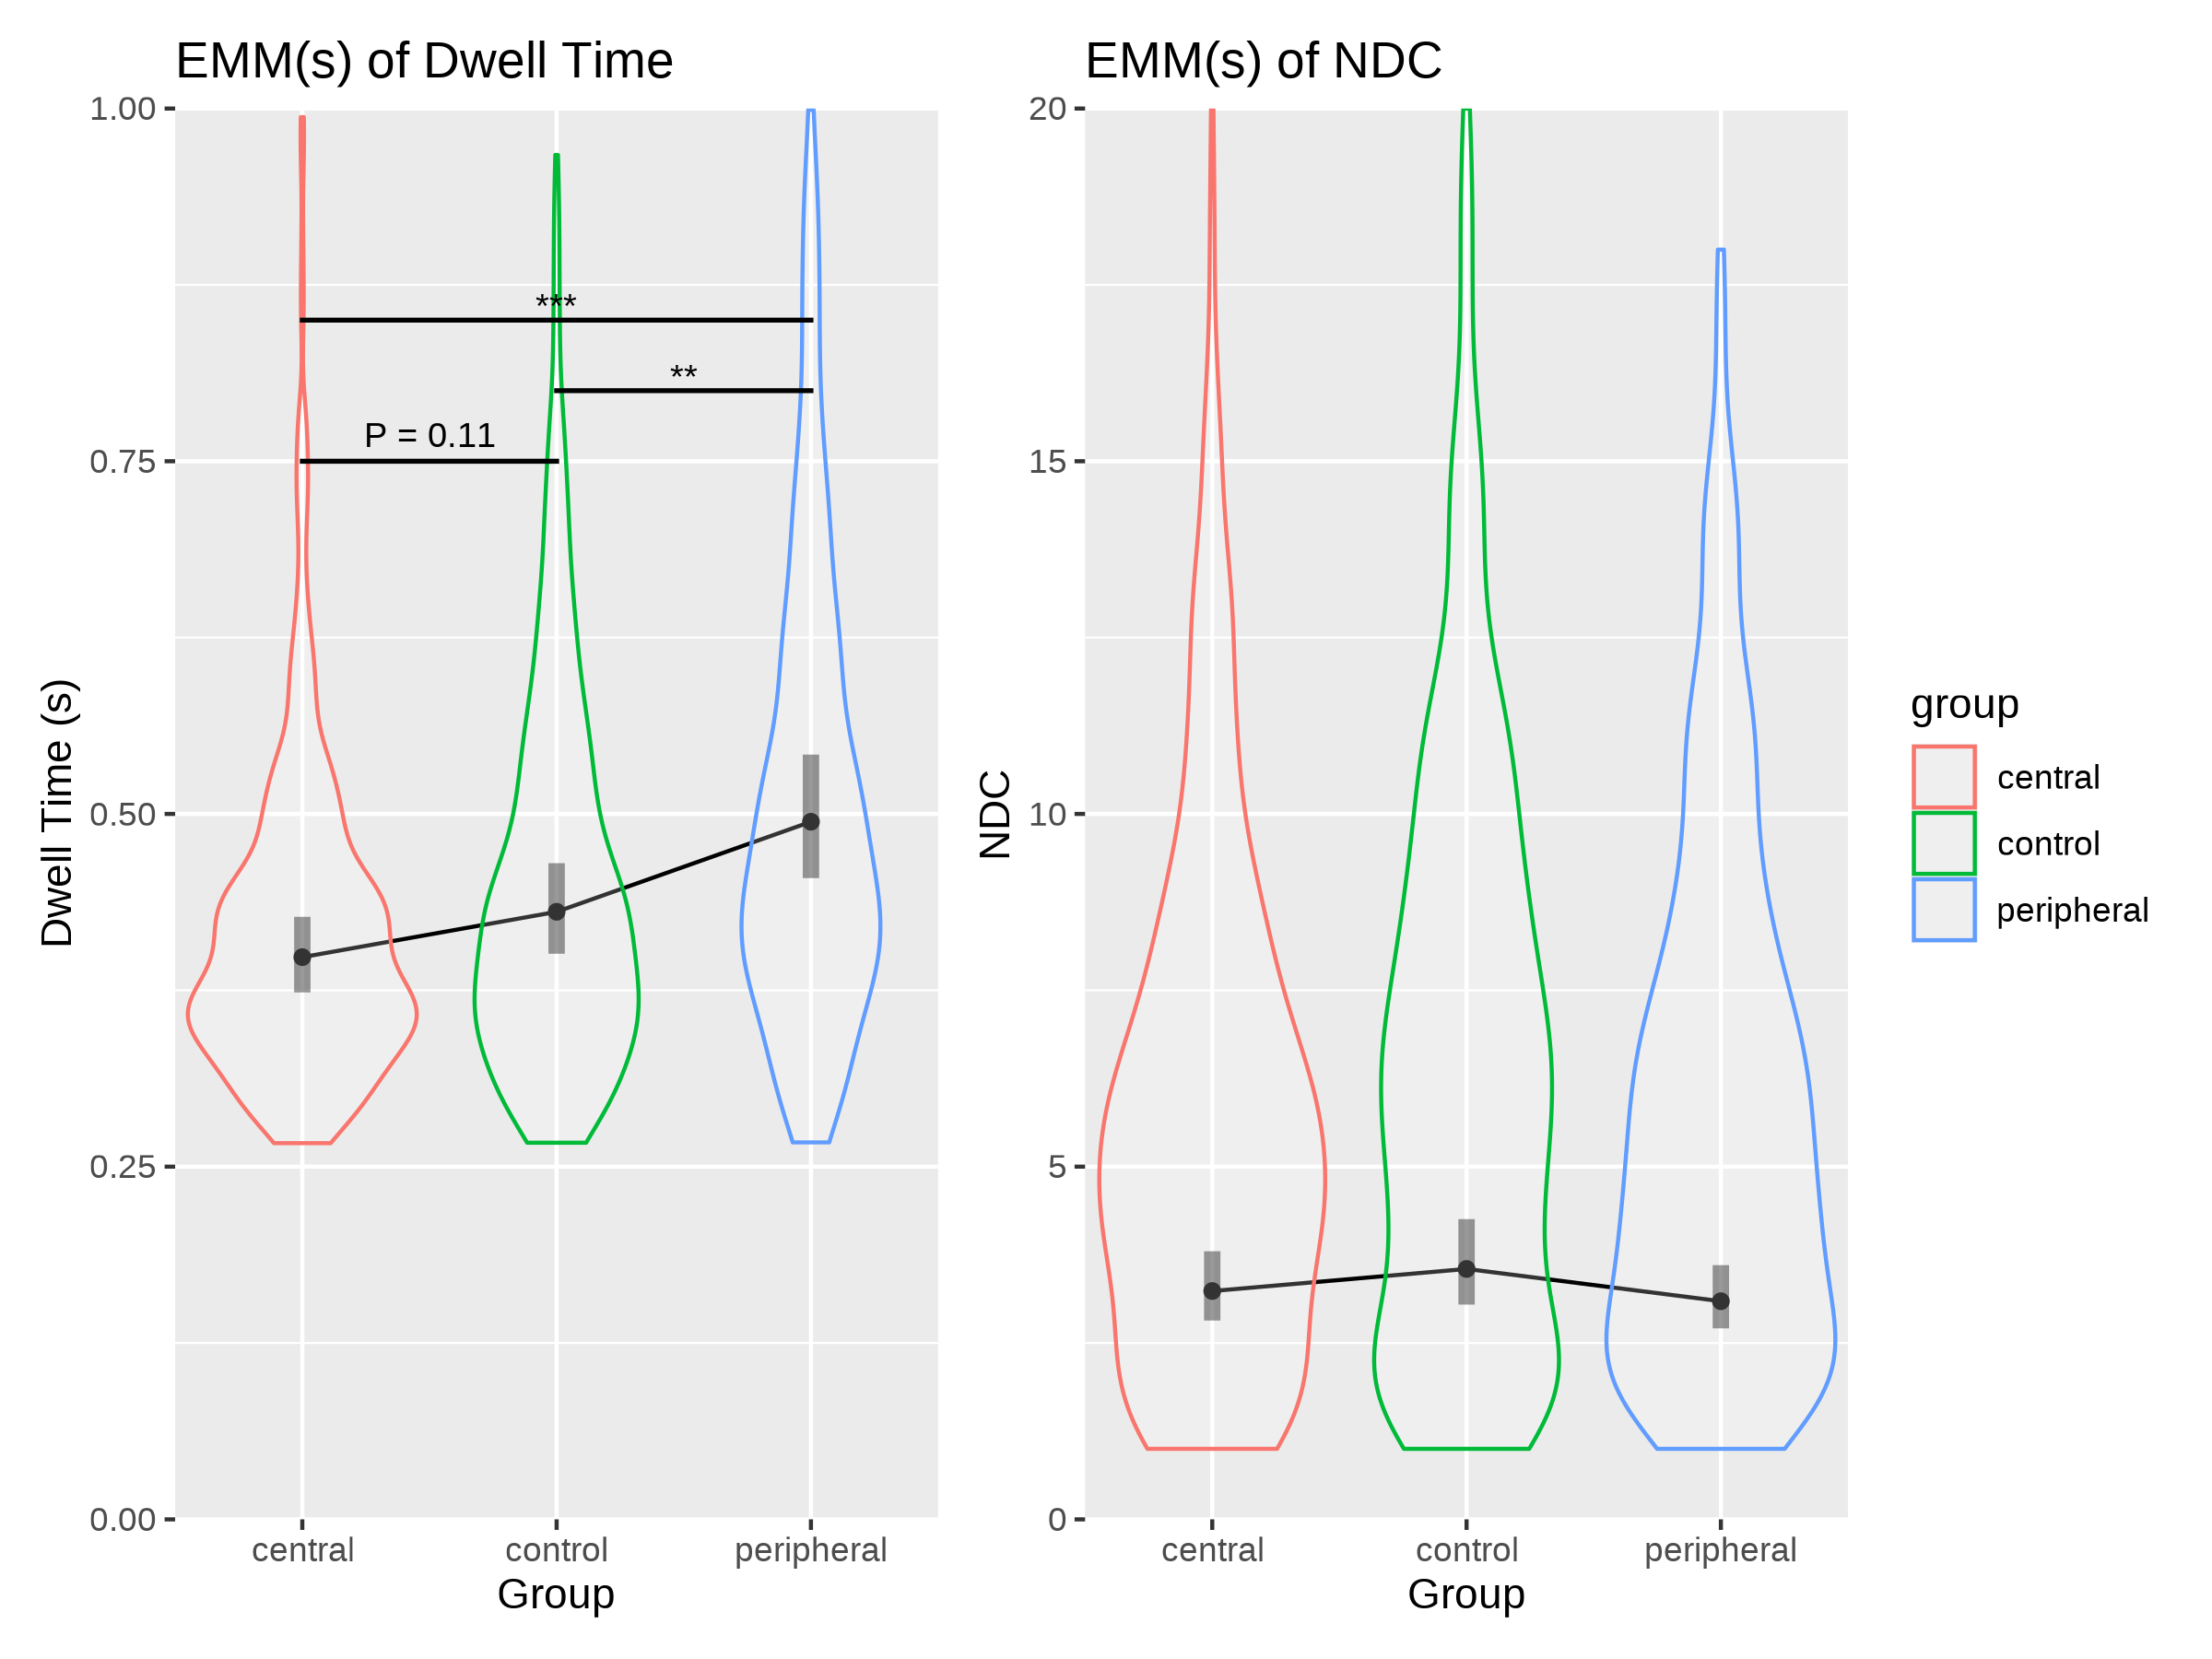

In [47]:
library(patchwork)
library(ggprism)

dwell_time_fig + ndc_mean_fig

In [15]:
dummy_data <- expand.grid(group = unique(df$group),
                          building_location = unique(df$building_location))
mm <- model.matrix(delete.response(terms(model)), dummy_data)
dummy_data$median_clusterDuration <-  1 / drop(mm %*% fixef(model))
predvar <- diag(mm %*% vcov(model) %*% t(mm))
dummy_data <- dummy_data %>%
    mutate(
        SE = sqrt(predvar),
        SE2 = sqrt(predvar + sigma(model)^2)
    )

[1] 0.4109216 0.4438699 0.3658845 0.5775331 0.3659341 0.3102803

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


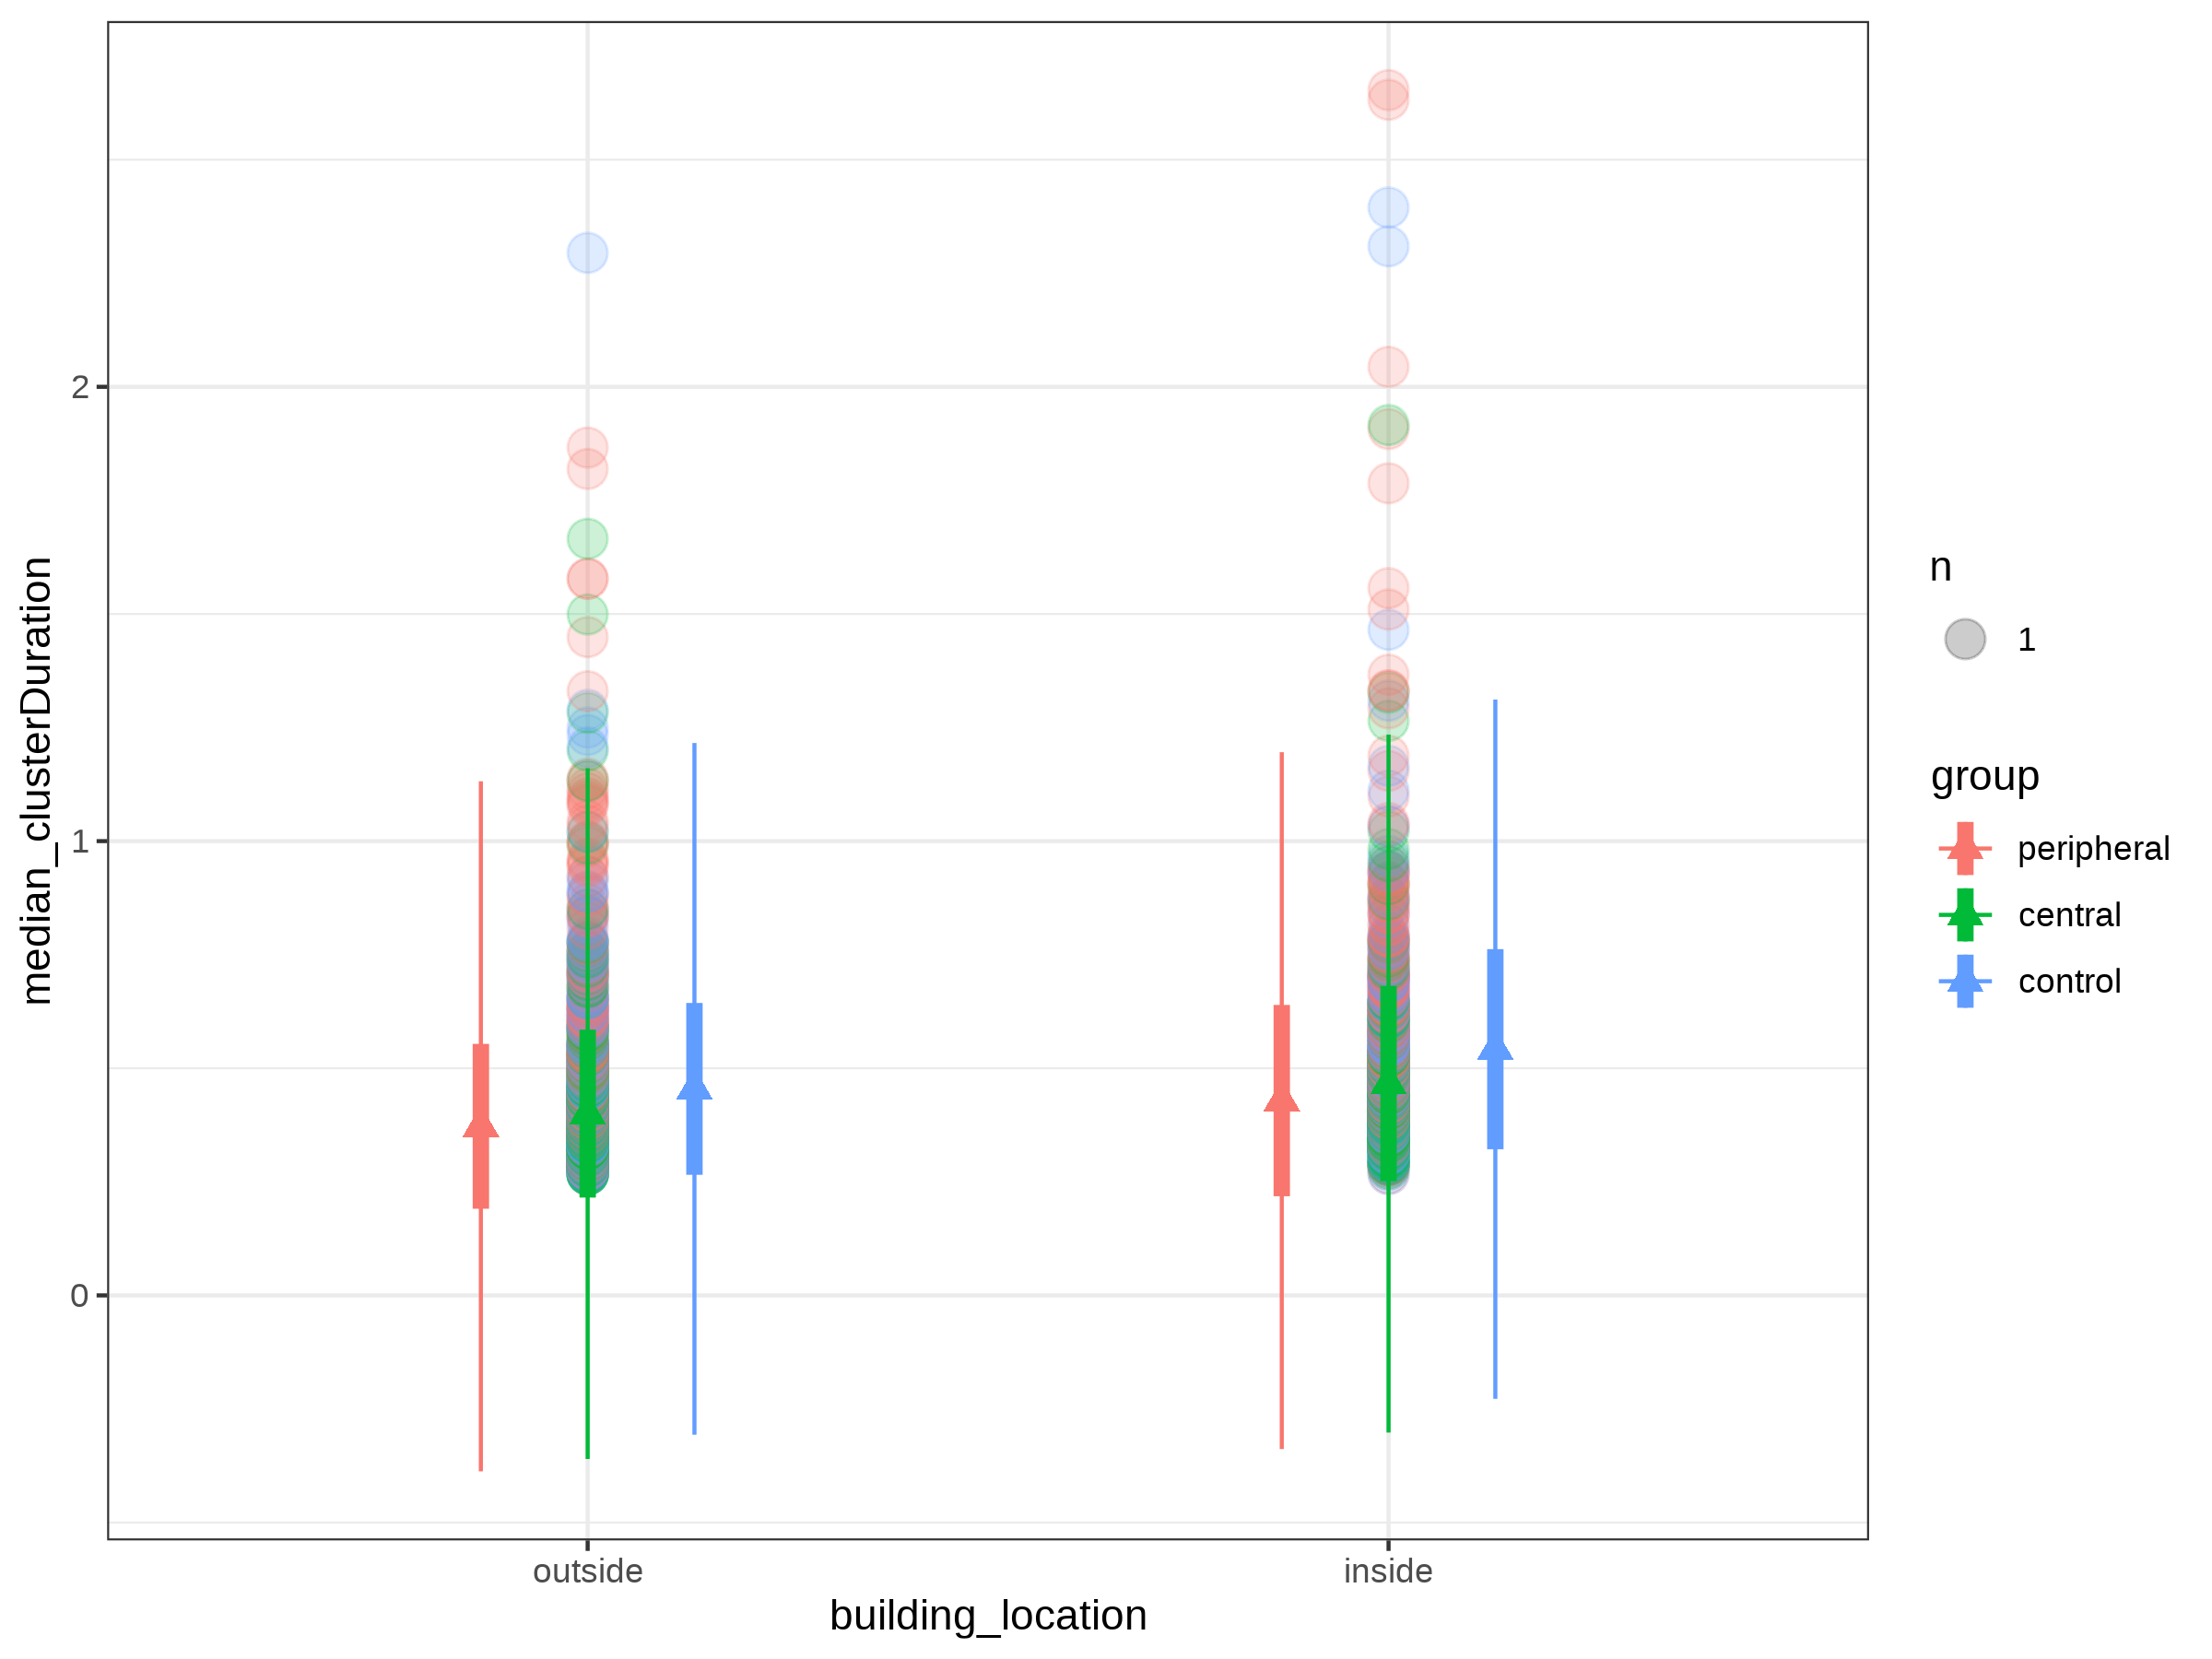

In [18]:
theme_set(theme_bw())
pd <- position_dodge(width=0.4)
df %>% pull(median_clusterDuration) %>% head()
g0 <- df %>% 
    ggplot(aes(x=building_location,y=median_clusterDuration,color=group)) + 
    stat_sum(alpha=0.2,aes(size=after_stat(n)))

g1 <- g0+geom_line(data=dummy_data,position=pd)+
    geom_point(data=dummy_data,shape=17,size=3,position=pd)

## confidence intervals
g2 <- g1 + geom_linerange(data=dummy_data,
                           aes(ymin=median_clusterDuration-2*SE,ymax=median_clusterDuration+2*SE),
                           lwd=2, position=pd)
# ## prediction intervals 
g2 + geom_linerange(data=dummy_data,
                  aes(ymin=median_clusterDuration-2*SE2,ymax=median_clusterDuration+2*SE2), position=pd)

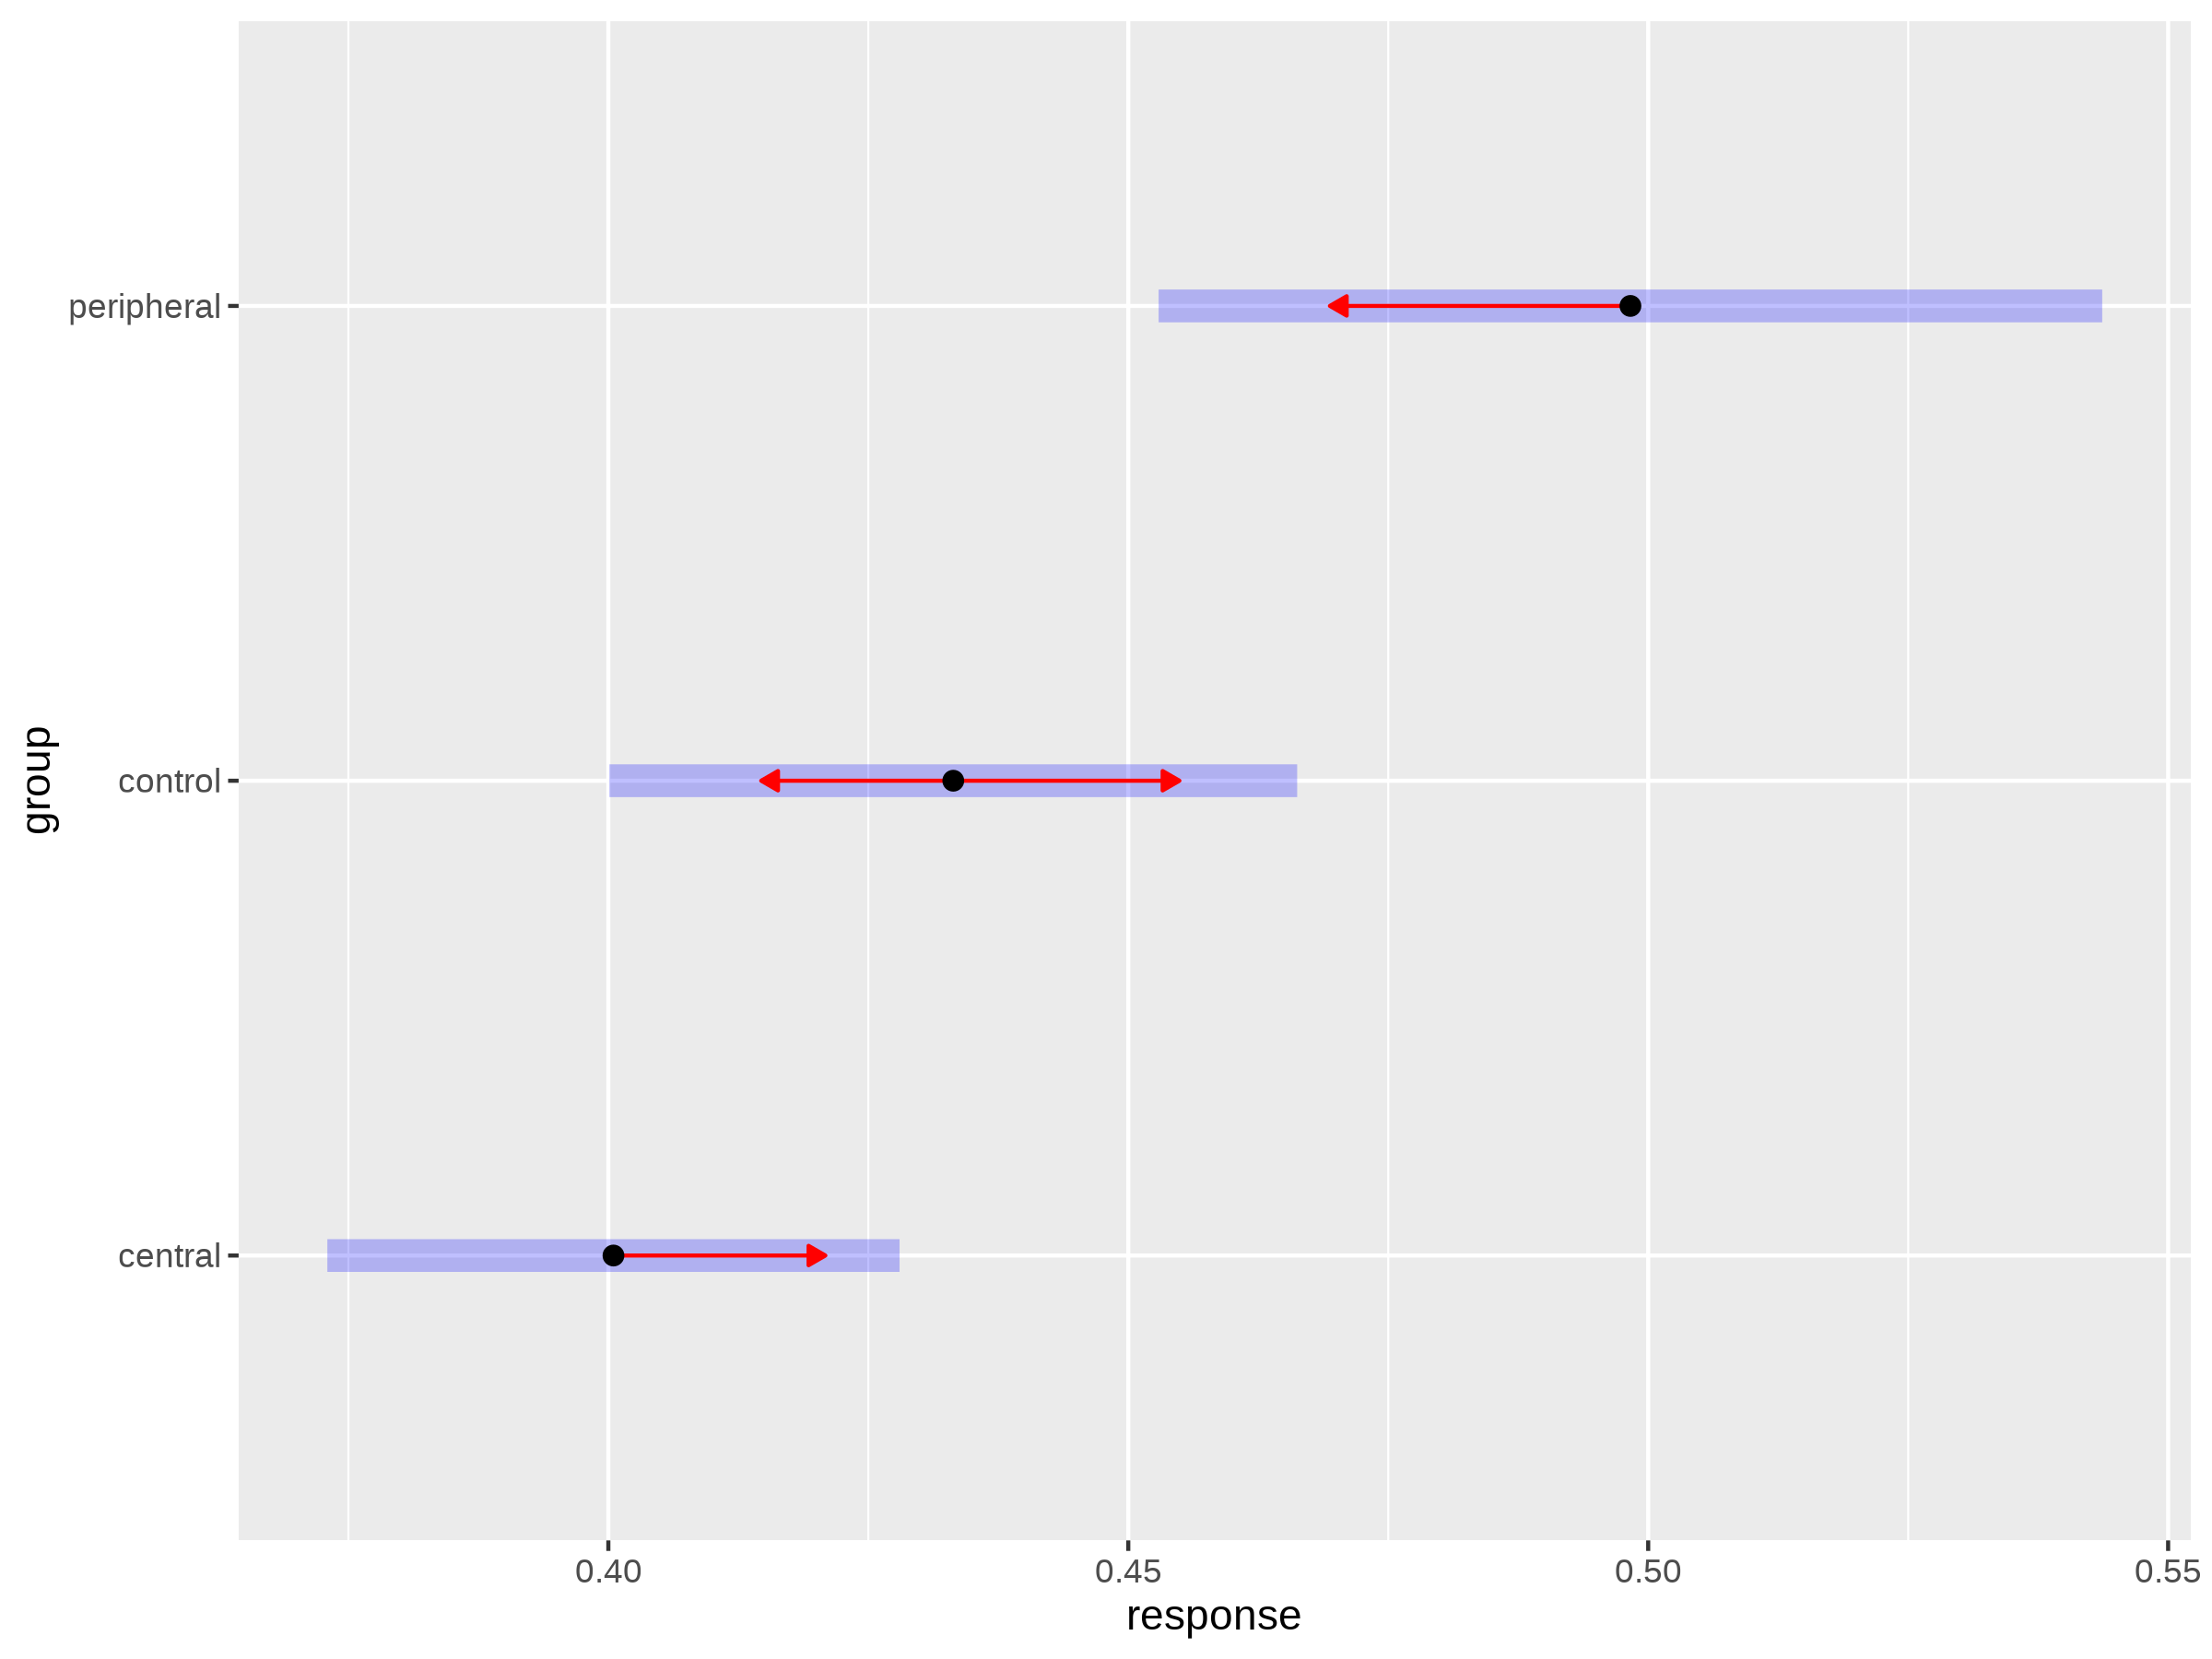

In [25]:
plot(emm, comparisons = TRUE)

In [16]:
r2_nakagawa(model, by_group = TRUE)
r2_nakagawa(model)

,Level,R2
,<chr>,<dbl>
,Level 1,0.02673548
PID,PID,0.03045502
hitObjectColliderName,hitObjectColliderName,0.16647961


# R2 for Mixed Models

  Conditional R2: 0.578
     Marginal R2: 0.176

In [8]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


In [9]:
pid_order <- df_node |> arrange(group) |> distinct(PID) |> pull(PID)

`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


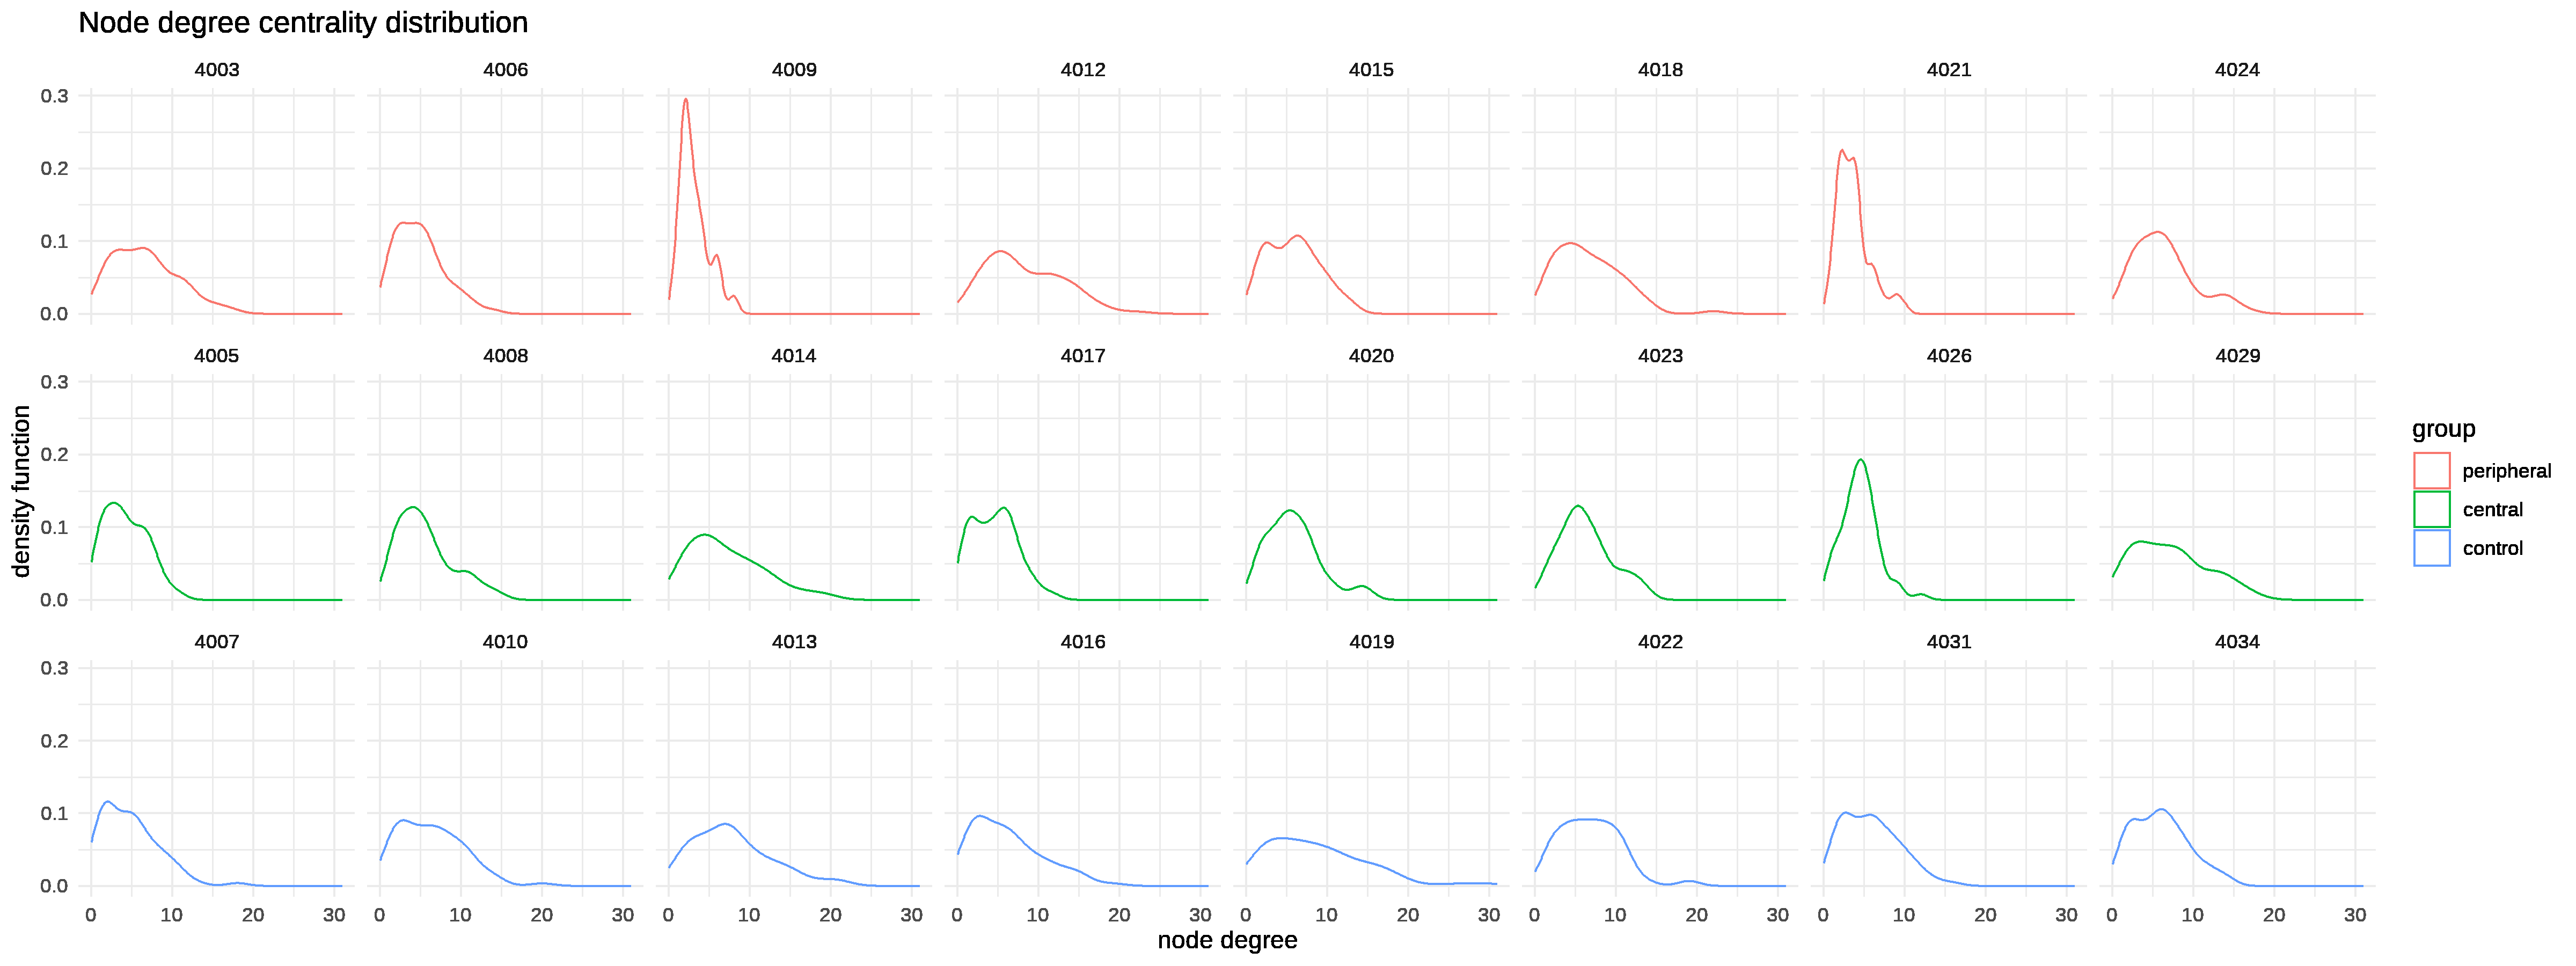

In [12]:
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 600)
fig <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup() |>
    ggplot(aes(x = connections, group = PID, color = group)) +
      # geom_histogram(bins = 50) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      facet_wrap(
          ~ factor(PID, pid_order),
          ncol = 8
      ) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Node degree centrality distribution",
           x = "node degree",
           y = "density function")
fig
ggsave("sim_indiv_node_degree_dist.svg", fig, width = 16, height = 6, units = "in", dpi = 600)
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)

In [20]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


In [27]:
# peripheral central control

group_df_node <- df_node |> group_by(group) |> group_split()

[1] 3

In [30]:
# connections
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[2]] |> pull(connections))
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[3]] |> pull(connections))
ks.test(group_df_node[[2]] |> pull(connections), group_df_node[[3]] |> pull(connections))

Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[2]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[2]], connections)
D = 0.070928, p-value = 2.091e-12
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[3]], connections)
D = 0.083856, p-value < 2.2e-16
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[2]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[2]], connections) and pull(group_df_node[[3]], connections)
D = 0.15109, p-value < 2.2e-16
alternative hypothesis: two-sided


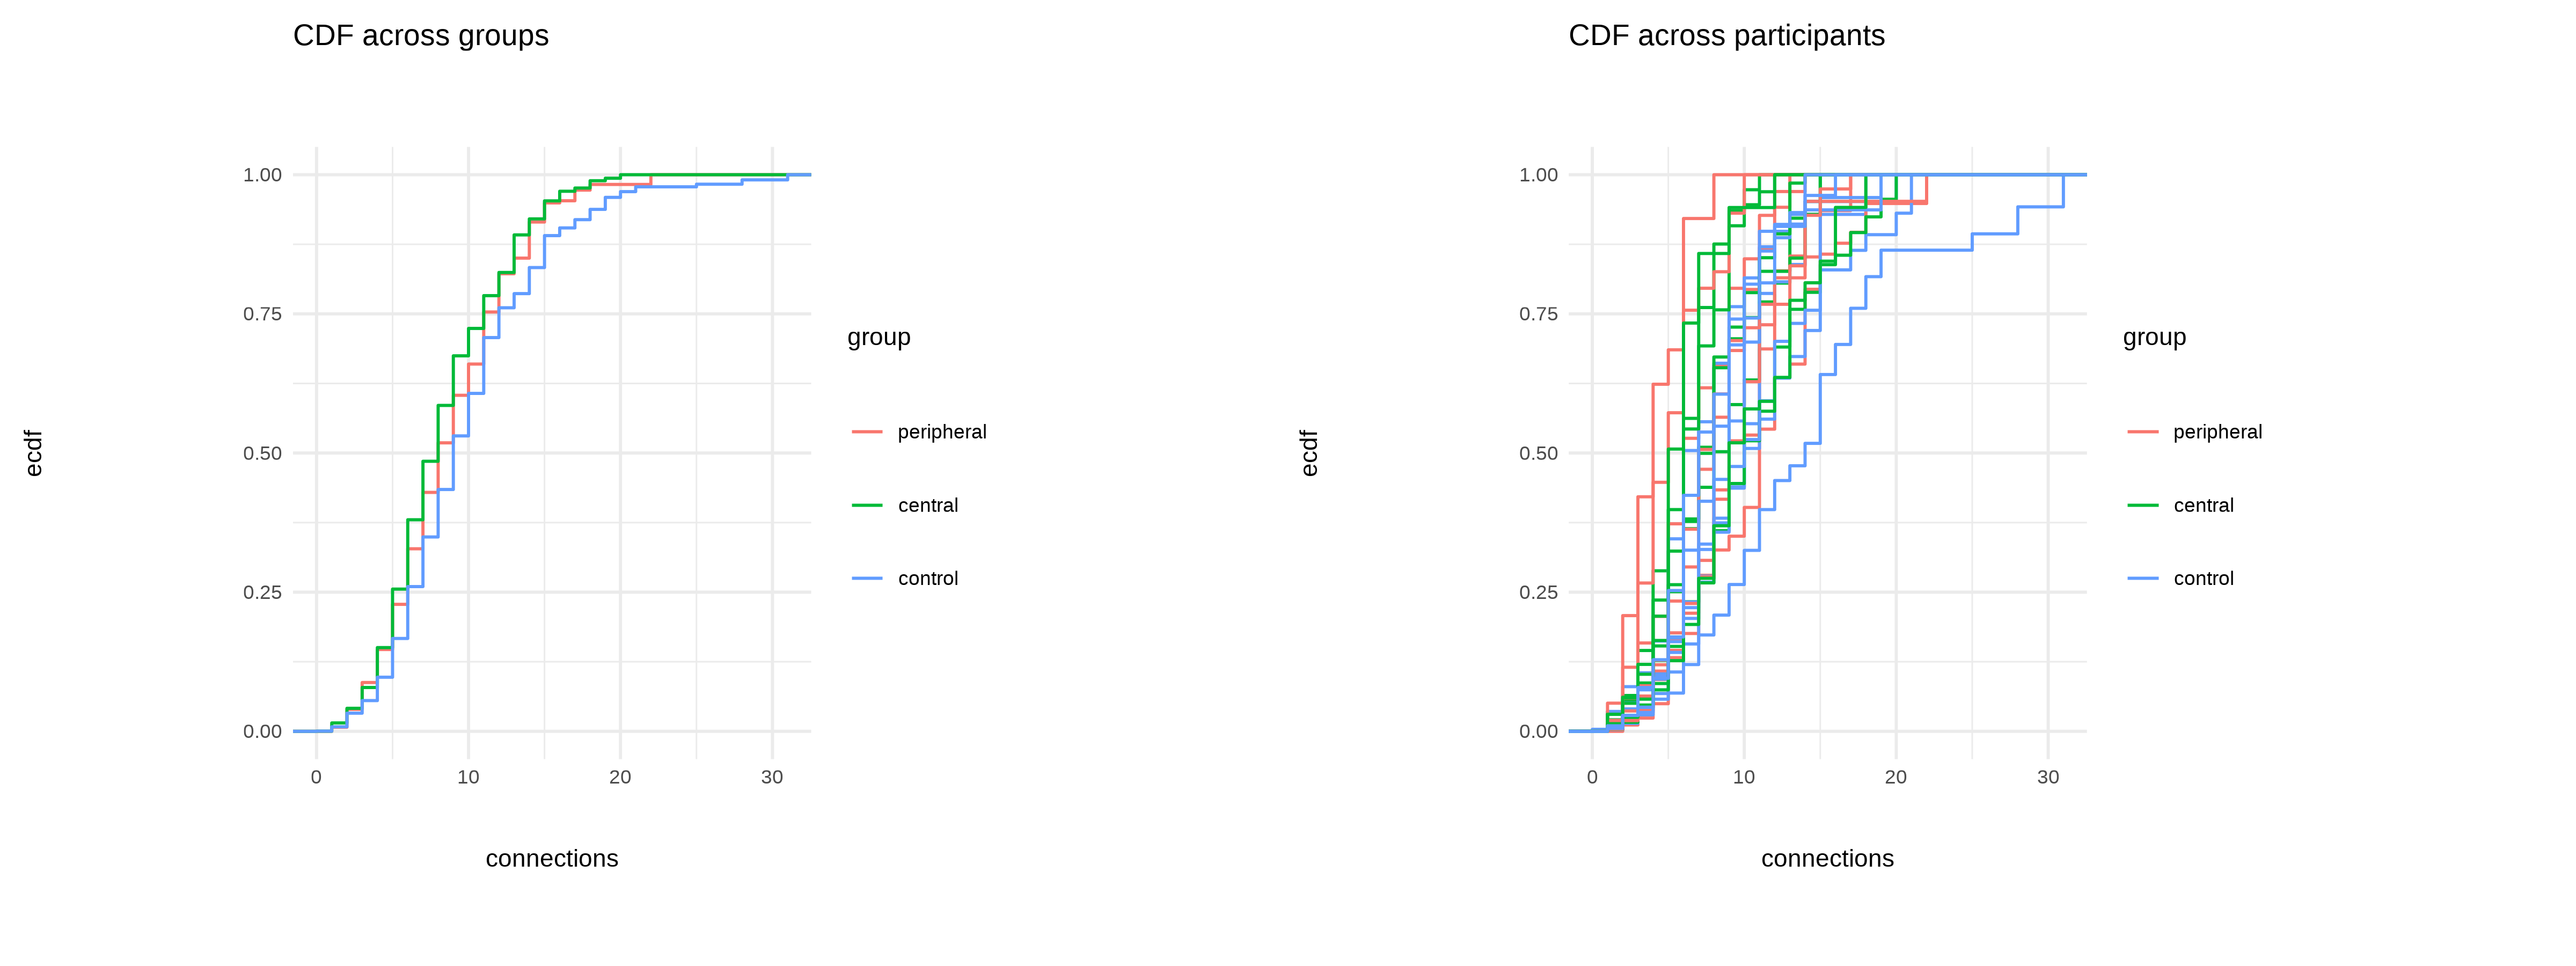

In [45]:
library(patchwork)
fig_group <- ggplot(df_node, aes(connections, group = group, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across groups") +
  theme_minimal()
fig_participants <- ggplot(df_node, aes(connections, group = PID, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across participants") + 
  theme_minimal()
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 300)
fig_group | fig_participants
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
ggsave("group_node_degree_ecdf.svg", fig_group | fig_participants, width = 16, height = 6, units = "in", dpi = 300)

In [72]:
plot_group_cdf_with_ribbon <- function(df, value_col, individual_col, group_col = NULL,
                                       probs = c(0.05, 0.95), x_points = 200) {
  # Create x grid
  x_grid <- df %>% pull({{ value_col }}) %>% range() %>%
    (\(rng) seq(rng[1], rng[2], length.out = x_points))()

  # Compute ECDFs
  ecdf_df <- df %>%
    nest(data = -c({{ group_col }}, {{ individual_col }})) %>%
    mutate(ecdf = map(data, ~ ecdf(pull(.x, {{ value_col }})))) %>%
    crossing(x = x_grid) %>%
    mutate(y = map2_dbl(ecdf, x, ~ .x(.y))) %>%
    select({{ group_col }}, {{ individual_col }}, x, y)

  # Summarize across individuals
  ecdf_summary <- ecdf_df %>%
    group_by({{ group_col }}, x) %>%
    summarize(
      ymin = quantile(y, probs[1]),
      ymax = quantile(y, probs[2]),
      ymed = median(y),
      .groups = "drop"
    )

  group_ecdf_df <- df %>%
      group_by({{ group_col }}) %>%
      summarize(data = list({{ value_col }}), .groups = "drop") %>%
      mutate(ecdf = map(data, ~ ecdf(.x))) %>%
      crossing(x = x_grid) %>%
      mutate(y = map2_dbl(ecdf, x, ~ .x(.y)))

  # Plot
  ggplot(ecdf_summary, aes(x = x, group = {{ group_col }}, fill = {{ group_col }}, color = {{ group_col }})) +
    geom_ribbon(aes(ymin = ymin, ymax = ymax), alpha = 0.3, color = NA) +
    geom_line(data = group_ecdf_df, aes(x = x, y = y, color = {{ group_col }}), size = 1) +
    theme_minimal() +
    labs(x = "node degree", y = "ECDF", title = "Group CDFs with Individual Variation",
         subtitle = paste0("Ribbon = ", probs[1]*100, "% to ", probs[2]*100, "% quantile of individuals")) +
    guides(fill = guide_legend(title = "Group"), color = guide_legend(title = "Group"))
}

Warning message in grid.Call.graphics(C_polygon, x$x, x$y, index):
“semi-transparency is not supported on this device: reported only once per page”


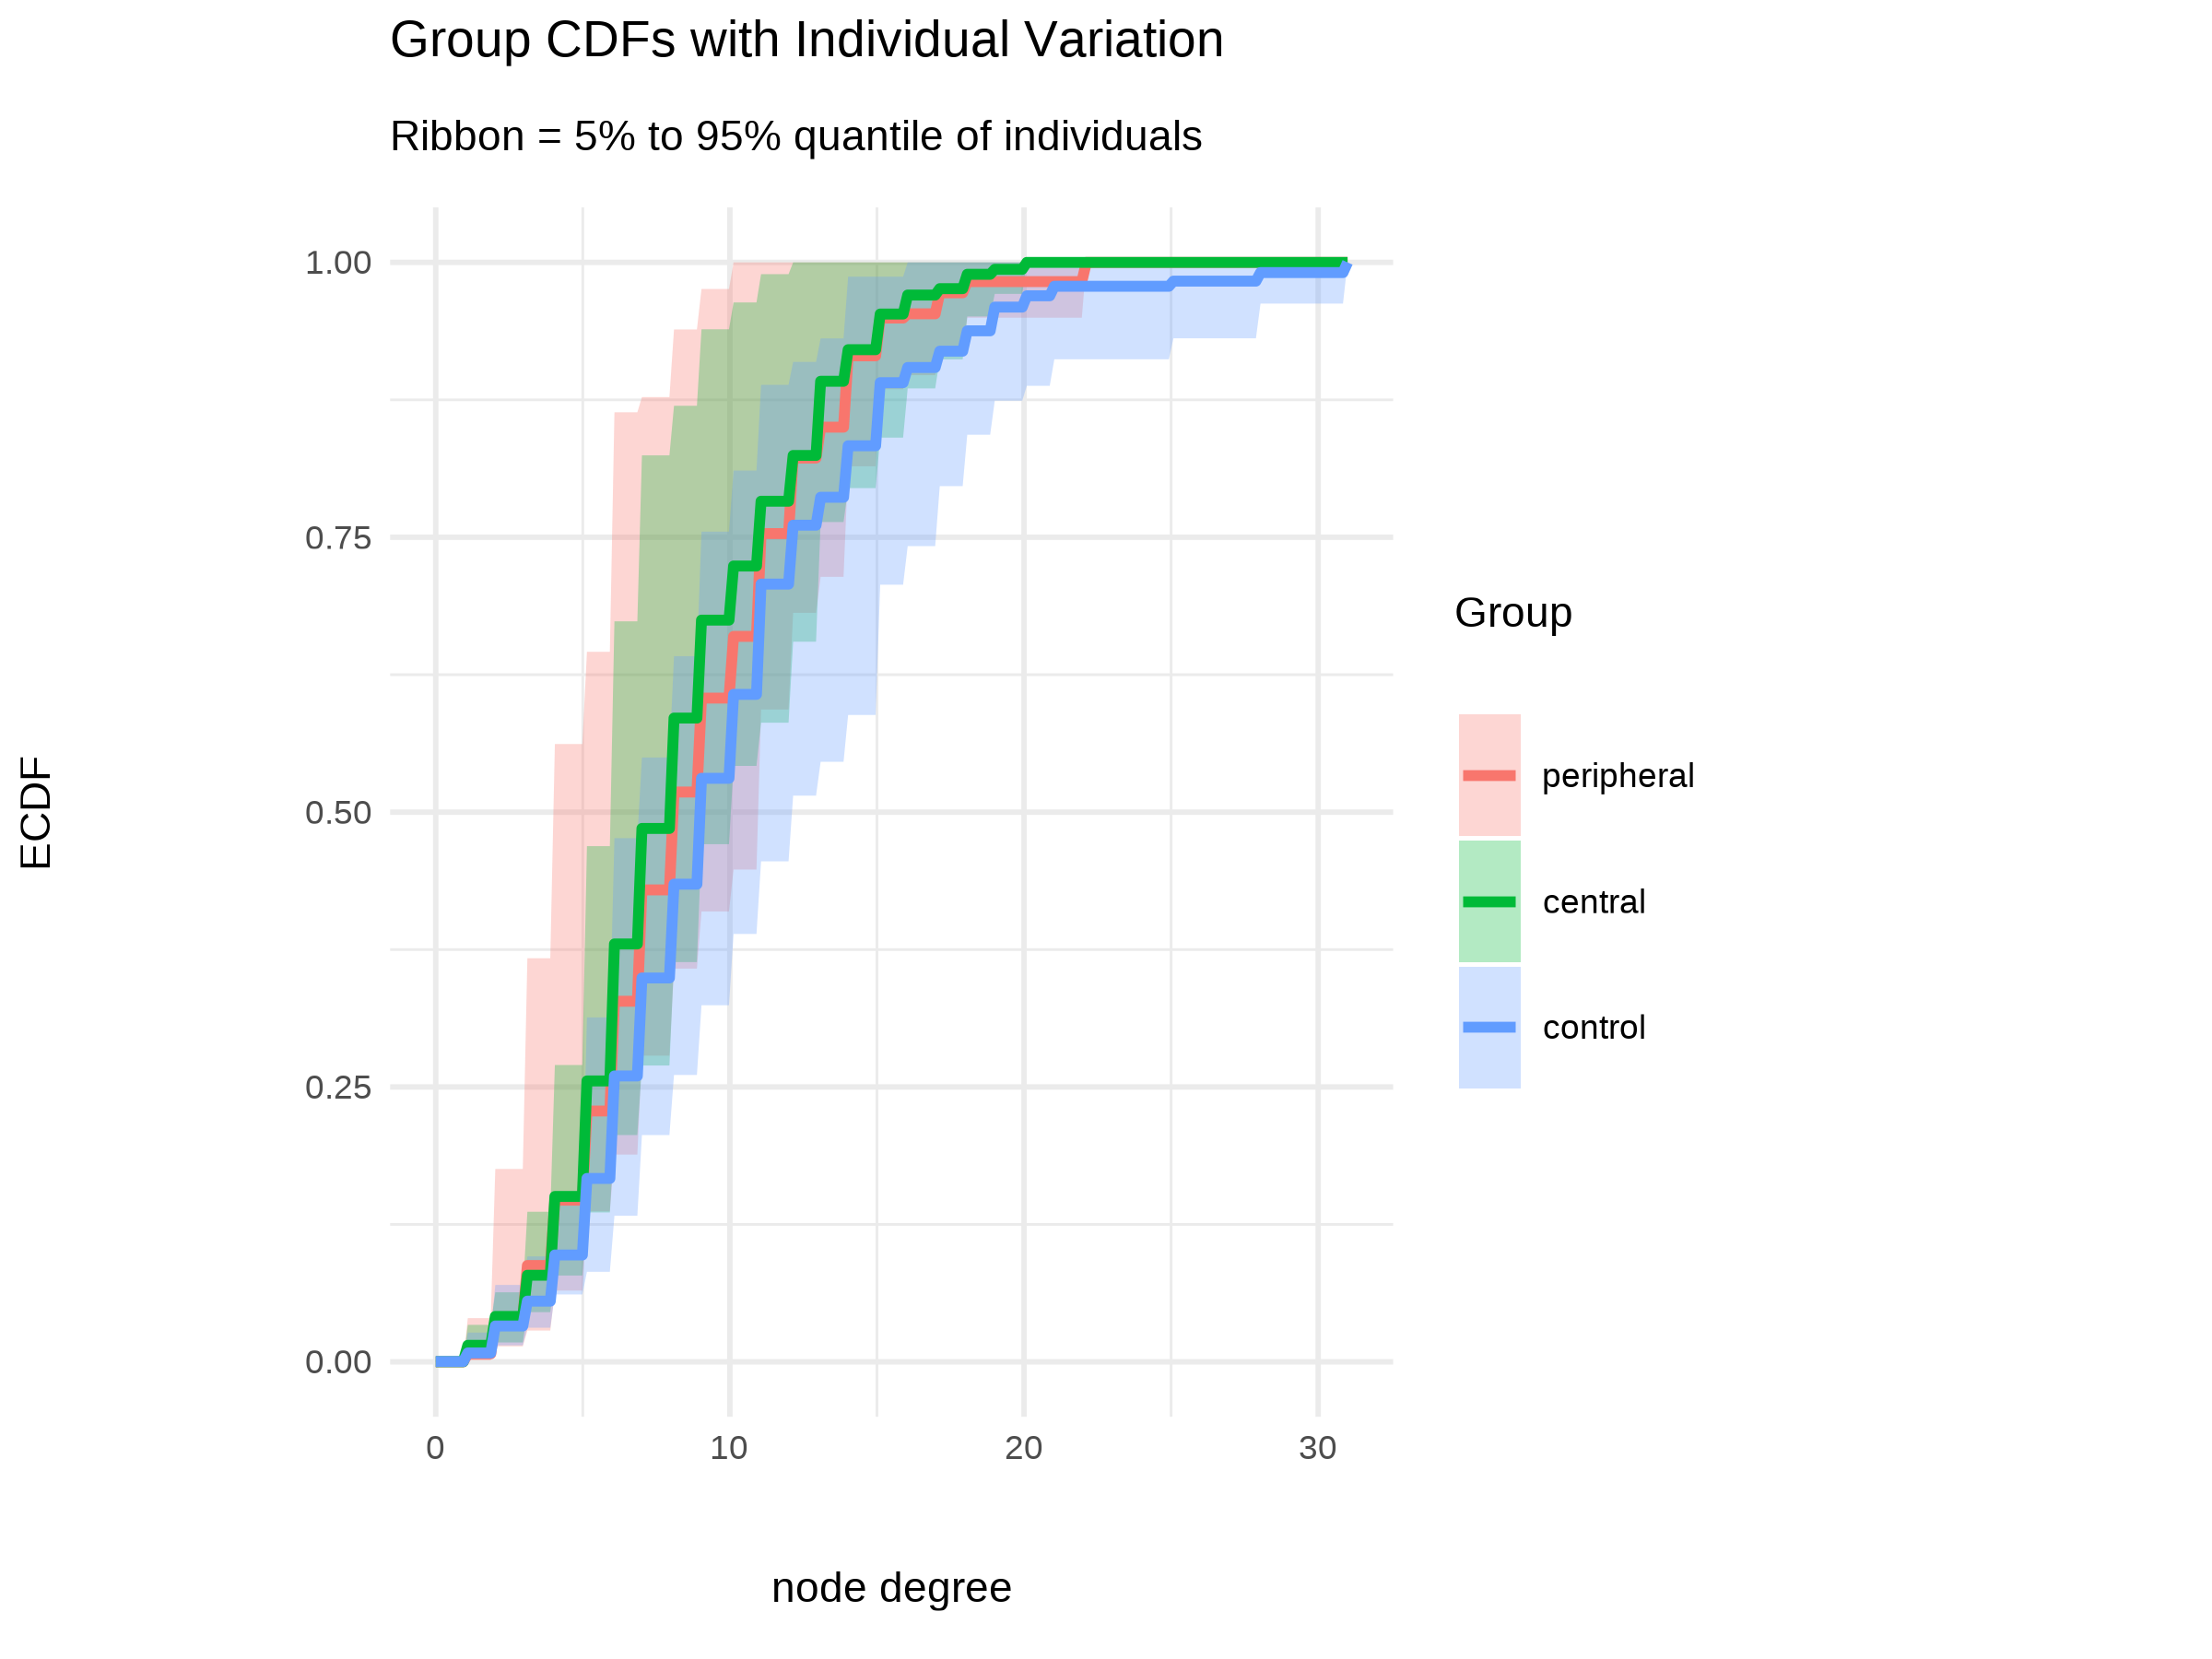

In [74]:
fig <- df_node |> plot_group_cdf_with_ribbon(connections, PID, group)
fig
# ggsave("group_node_degree_ecdf.svg", fig, width = 6, height = 6, units = "in", dpi = 300)

ERROR while rich displaying an object: Error in `geom_density()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'clusterDuration' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = er

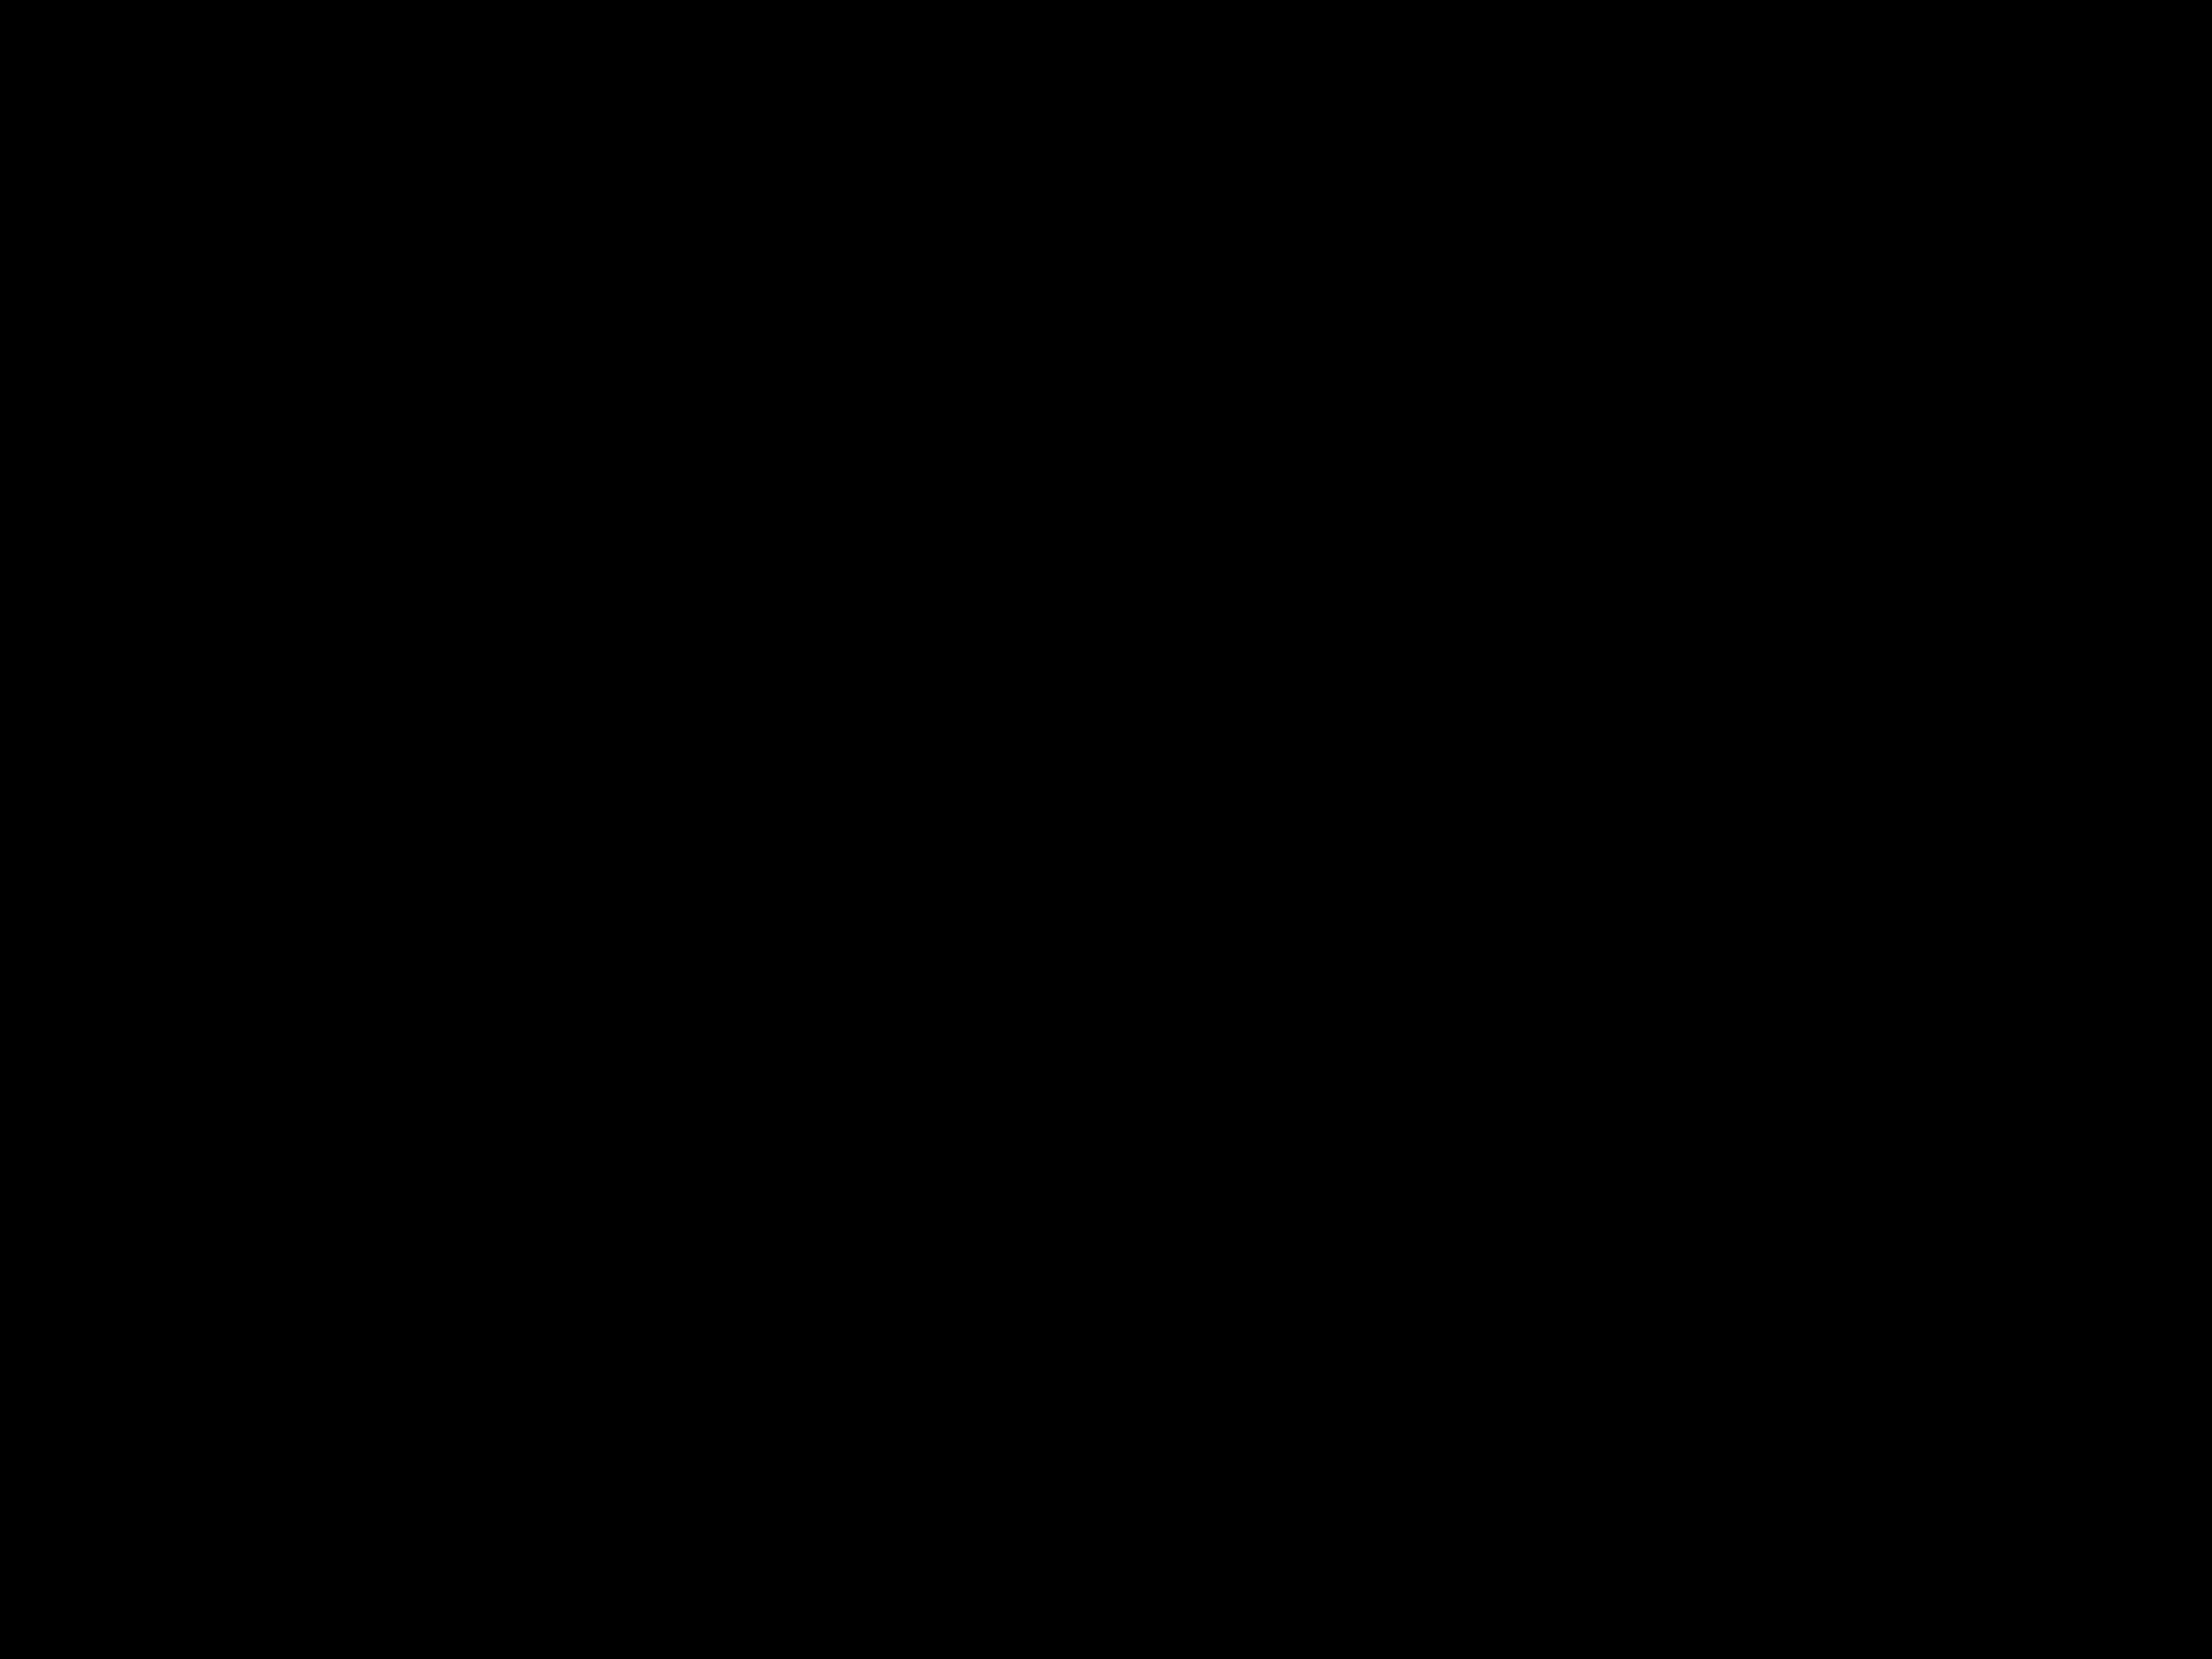

In [21]:
df_node |>
  ggplot(aes(x = clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0,1)+
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")

In [22]:
df <- read_csv("graph_group_connections.csv")
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
fig <- df |>
  ggplot(aes(x = connections, group = group, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  theme_minimal() +
  labs(title = "Node degree centrality distribution",
       x = "node degree",
       y = "density")
#ggsave("sim_node_degree_dist.svg", fig)
fig

df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Saving 6.67 x 6.67 in image


In [64]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group * building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [63]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,4.350301,0.1925744,Inf,3.972862,4.727740
2,inside,6.887977,0.4680248,Inf,5.970666,7.805289


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

In [65]:
model
library(car)
Anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: connections ~ group * building_location + (1 | PID)
   Data: df_rm_null
      AIC       BIC    logLik  deviance  df.resid 
 9238.169  9282.248 -4611.084  9222.169      1818 
Random effects:
 Groups   Name        Std.Dev.
 PID      (Intercept) 0.02747 
 Residual             0.57017 
Number of obs: 1826, groups:  PID, 24
Fixed Effects:
                         (Intercept)                          groupcentral  
                            0.237722                              0.003478  
                        groupcontrol               building_locationinside  
                           -0.024330                             -0.072348  
groupcentral:building_locationinside  groupcontrol:building_locationinside  
                           -0.017550                             -0.016438  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
group,2.619834,2,2.698424e-01
building_location,310.818873,1,1.448236e-69
group:building_location,2.724093,2,2.561361e-01
